In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import folium
from folium import plugins
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score
from math import sqrt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

In [ ]:
# Load the DataFrame from the pickle file
taxidata_copy = pd.read_pickle('/content/drive/MyDrive/PolyU/Year2/EIE4117/dataset/taxidata_processed2.pkl')
display(taxidata_copy.head())

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE,DATE,HOUR,MINUTE,DAY_MONTH,DAY,MONTH,YEAR,PICKUP_LOC,LENGHT,DROP_OFF_LOC
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[...",2013-07-01,0,0,1,0,7,2013,"[41.141412, -8.618643]",500,"[41.154489, -8.630838]"
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[...",2013-07-01,0,8,1,0,7,2013,"[41.159826, -8.639847]",413,"[41.170671, -8.66574]"
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-...",2013-07-01,0,2,1,0,7,2013,"[41.140359, -8.612964]",1408,"[41.14053, -8.61597]"
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[...",2013-07-01,0,0,1,0,7,2013,"[41.151951, -8.574678]",938,"[41.142915, -8.607996]"
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-...",2013-07-01,0,4,1,0,7,2013,"[41.18049, -8.645994]",634,"[41.178087, -8.687268]"


# Data Cleaning, Data Preprocessing and Feature Engineering

In [ ]:
!unzip -q '/content/drive/MyDrive/PolyU/Year2/EIE4117/dataset/dataset.zip'
# we need change to specific folder that have dataset

In [ ]:
taxidata = pd.read_csv('/content/train.csv')
# input dataset

In [ ]:
taxidata.count()

,0
TRIP_ID,1710670
CALL_TYPE,1710670
ORIGIN_CALL,364770
ORIGIN_STAND,806579
TAXI_ID,1710670
TIMESTAMP,1710670
DAY_TYPE,1710670
MISSING_DATA,1710670
POLYLINE,1710670


In [ ]:
taxidata.head()

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."


In [ ]:
taxidata.isna().sum()

,0
TRIP_ID,0
CALL_TYPE,0
ORIGIN_CALL,1345900
ORIGIN_STAND,904091
TAXI_ID,0
TIMESTAMP,0
DAY_TYPE,0
MISSING_DATA,0
POLYLINE,0


In [ ]:
count = taxidata.MISSING_DATA.value_counts()
count

,count
MISSING_DATA,
False,1710660
True,10


In [ ]:
count = taxidata.POLYLINE.value_counts()['[]']
count

np.int64(5901)

In [ ]:
# remove missing GPS data
taxidata = taxidata[taxidata.MISSING_DATA != True]
# remove empty polyline
taxidata = taxidata[taxidata.POLYLINE != '[]']

In [ ]:
# converting UNIX time to a readable one
# converting WGS84 format into readable one
taxidata_copy = taxidata.copy()
taxidata_copy['DATE'] = taxidata_copy.TIMESTAMP.apply(lambda x: dt.datetime.fromtimestamp(x).date())
taxidata_copy['HOUR'] = taxidata_copy.TIMESTAMP.apply(lambda x: dt.datetime.fromtimestamp(x).hour)
taxidata_copy['MINUTE'] = taxidata_copy.TIMESTAMP.apply(lambda x: dt.datetime.fromtimestamp(x).minute)
taxidata_copy['DAY_MONTH'] = taxidata_copy.TIMESTAMP.apply(lambda x: dt.datetime.fromtimestamp(x).day)
taxidata_copy['DAY'] = taxidata_copy.TIMESTAMP.apply(lambda x: dt.datetime.fromtimestamp(x).weekday())
taxidata_copy['MONTH'] = taxidata_copy.TIMESTAMP.apply(lambda x: dt.datetime.fromtimestamp(x).month)
taxidata_copy['YEAR'] = taxidata_copy.TIMESTAMP.apply(lambda x: dt.datetime.fromtimestamp(x).year)
#this line takes a while to run
taxidata_copy['PICKUP_LOC'] = taxidata_copy.POLYLINE.apply(lambda x: eval(x.split()[0])[0])
taxidata_copy['PICKUP_LOC'] = taxidata_copy.PICKUP_LOC.apply(lambda x: np.flip(x,0))
taxidata_copy['DROP_OFF_LOC'] = taxidata_copy.POLYLINE.apply(lambda x: np.flip(eval(x)[-1], 0)) # Added this line for optimization
taxidata_copy['LENGHT'] = taxidata_copy.POLYLINE.apply(lambda x: len(x))

taxidata_copy.head()

# 1372636858 => Mon Jul 01 2013 00:00:58
# Around 10 minutes to convert and apply

KeyboardInterrupt: 

In [ ]:
# Save the DataFrame to a pickle file
taxidata_copy.to_pickle('/content/drive/MyDrive/PolyU/Year2/EIE4117/dataset/taxidata_processed.pkl')
print("Processed data saved to taxidata_processed.pkl")

NameError: name 'taxidata_copy' is not defined

In [ ]:
# Load the DataFrame from the pickle file
taxidata_copy = pd.read_pickle('/content/drive/MyDrive/PolyU/Year2/EIE4117/dataset/taxidata_processed.pkl')
display(taxidata_copy.head())

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE,DATE,HOUR,MINUTE,DAY_MONTH,DAY,MONTH,YEAR,PICKUP_LOC,LENGHT
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[...",2013-07-01,0,0,1,0,7,2013,"[41.141412, -8.618643]",500
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[...",2013-07-01,0,8,1,0,7,2013,"[41.159826, -8.639847]",413
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-...",2013-07-01,0,2,1,0,7,2013,"[41.140359, -8.612964]",1408
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[...",2013-07-01,0,0,1,0,7,2013,"[41.151951, -8.574678]",938
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-...",2013-07-01,0,4,1,0,7,2013,"[41.18049, -8.645994]",634


In [ ]:
def showmap(day = 0, call_type = 'C', type_map = 'h', nmarker = 500):
    """
    this a function to show a map with either a heatmap or a marker usinf folium library
    day ranges from 0 to 6
    call_type is either A , B or C
    type_map : ['m', 'h']
    nmarker is the number of marker to displayed chosen from the begining of the array
    """
    if type_map != 'm' and type_map != 'h':
        print('chose between "h" or "m"')
    elif day > 6 or day < 0:
        print('chose a day between [0-6]')
    else:
        day = day
        taxidata_c = taxidata_copy.copy()
        taxidata_c = taxidata_c[taxidata_c.CALL_TYPE == call_type]
        day_route = taxidata_c[taxidata_c.DAY == day].PICKUP_LOC.tolist()
        day_map = folium.Map([41.1579,-8.6291], zoom_start=10, tiles='OpenStreetMap', attr='OpenStreetMap')
        if type_map == 'h':
            plugins.HeatMap(day_route, radius=11).add_to(day_map)
        elif type_map == 'm':
            for i in range(nmarker):
                folium.Marker([day_route[i][0], day_route[i][1]]).add_to(day_map)

        display(day_map)

In [ ]:
showmap(day = 3, call_type = 'C', type_map = 'h')

In [ ]:
showmap(day = 6, call_type = 'C', type_map = 'm')

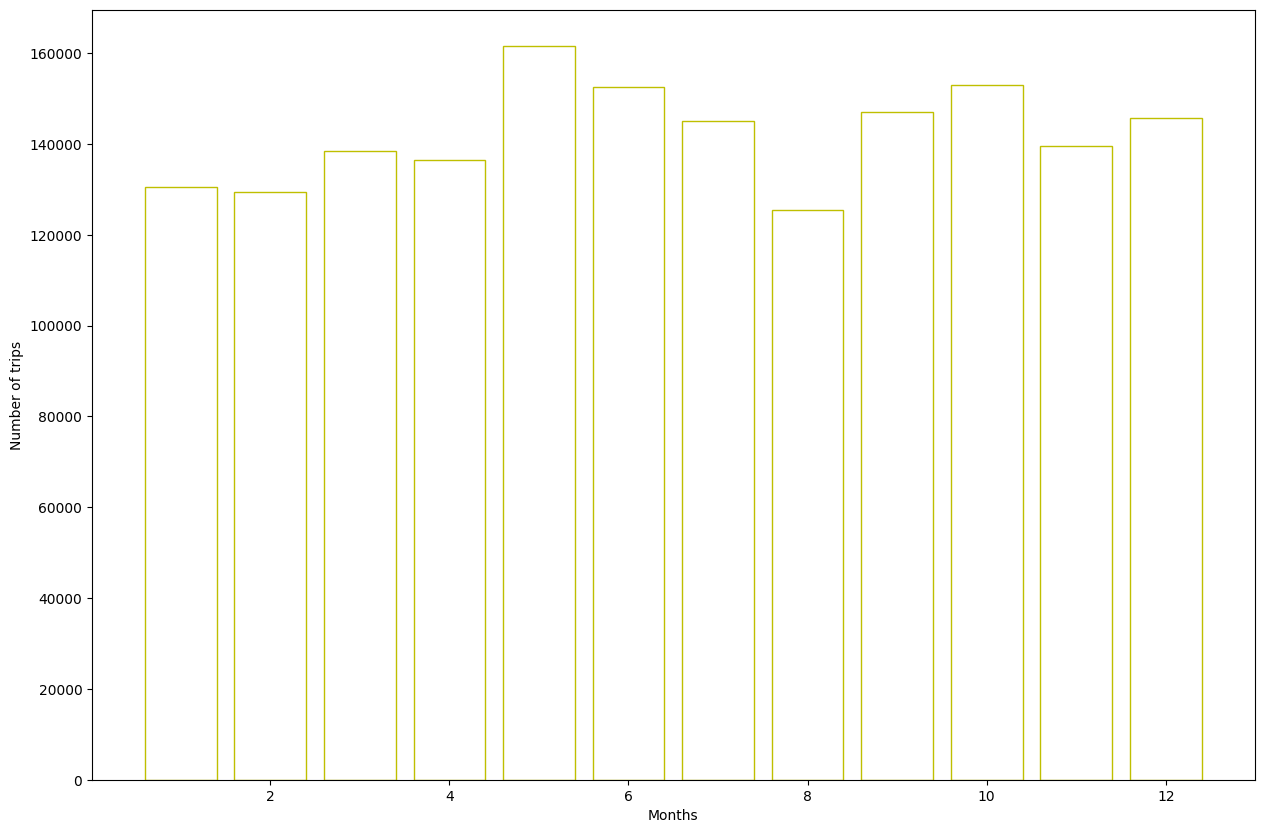

In [ ]:
plt.figure(figsize=(15,10))
ax = plt.bar(
        taxidata_copy.MONTH.value_counts().keys()
        , taxidata_copy.MONTH.value_counts().values
        , color = 'w'
        , edgecolor = 'y')
plt.xlabel('Months')
plt.ylabel('Number of trips')
plt.show()

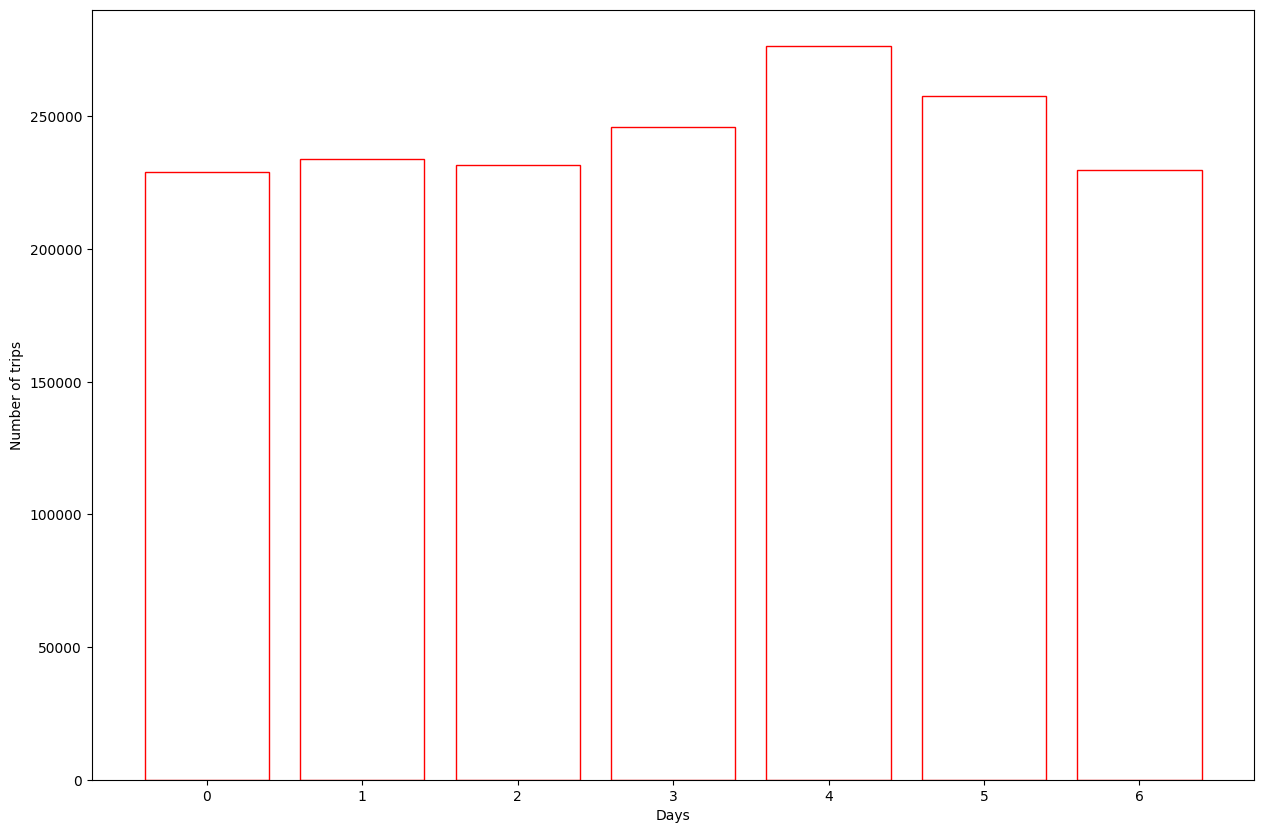

In [ ]:
plt.figure(figsize=(15,10))
ax = plt.bar(
        taxidata_copy.DAY.value_counts().keys()
        , taxidata_copy.DAY.value_counts().values
        , color = 'w'
        , edgecolor = 'r')
plt.xlabel('Days')
plt.ylabel('Number of trips')
plt.show()

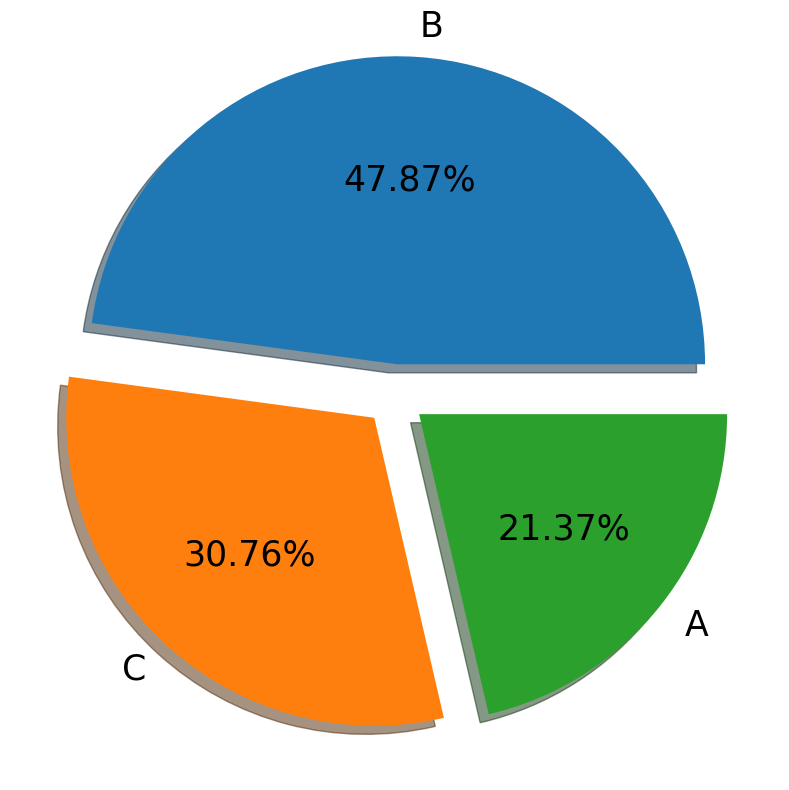

In [ ]:
plt.figure(figsize=(15,10))
explode = (0.1, 0.1, 0.1)
plt.rc('font', size=25)
ax = plt.pie(
        explode = explode
        ,labels = taxidata_copy.CALL_TYPE.value_counts().keys()
        ,x = taxidata_copy.CALL_TYPE.value_counts().values
        ,shadow=True
        ,autopct='%1.2f%%')
plt.show()

Text(0, 0.5, 'Day')

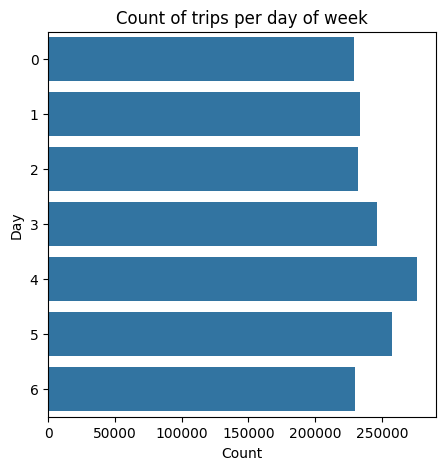

In [ ]:
plt.figure(figsize = (5,5))
plt.title('Count of trips per day of week')
sns.countplot(y = 'DAY', data = taxidata_copy)
plt.xlabel('Count')
plt.ylabel('Day')

Text(0, 0.5, 'Month')

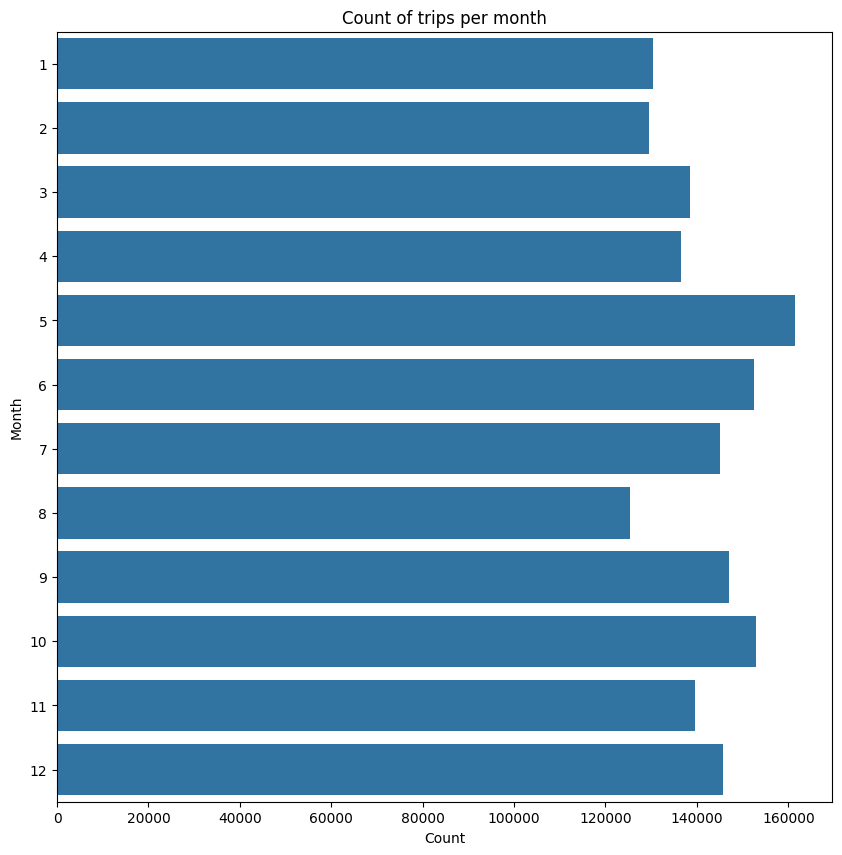

In [ ]:
plt.figure(figsize = (10,10))
plt.title('Count of trips per month')
sns.countplot(y = 'MONTH', data = taxidata_copy)
plt.xlabel('Count')
plt.ylabel('Month')

Text(0, 0.5, 'Hours')

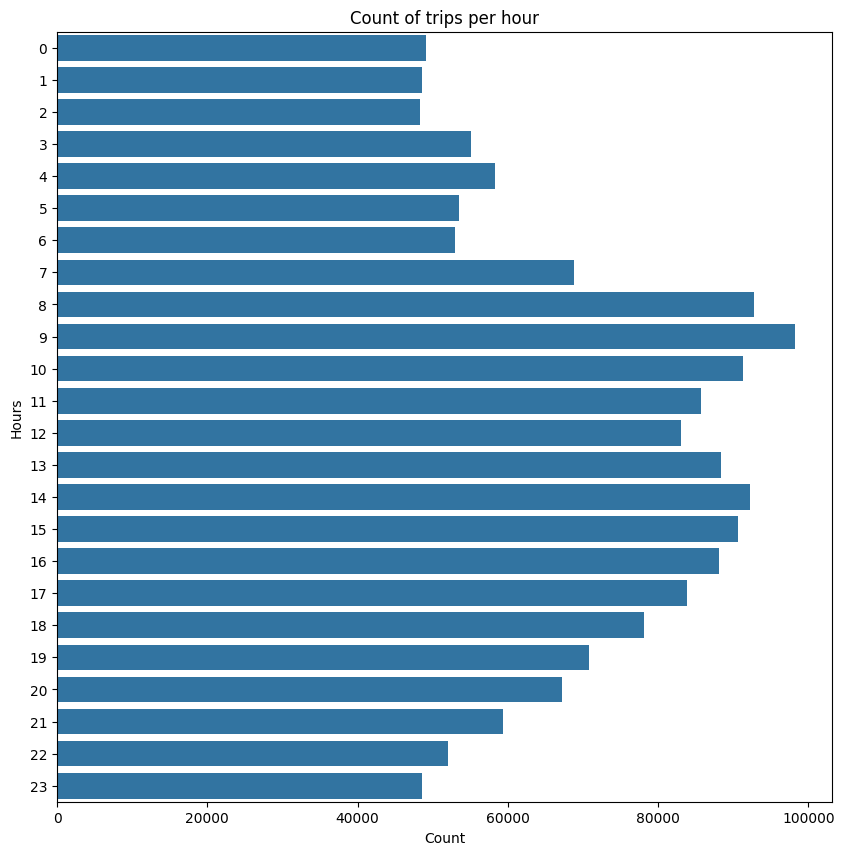

In [ ]:
plt.figure(figsize = (10,10))
plt.title('Count of trips per hour')
sns.countplot(y = 'HOUR', data = taxidata_copy)
plt.xlabel('Count')
plt.ylabel('Hours')

# Task
trip times<br>
distance_and_direction


In [ ]:
!pip install flask-ngrok
!pip install osmnx networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.2 MB/s eta 0:00:00


In [ ]:
!pip install Flask-WTF
!pip install flask-talisman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.5/152.5 kB 4.4 MB/s eta 0:00:00


In [ ]:
# Define the map dataset from OpenStreetMap
import osmnx as ox

# Define the place
place_name = "Porto, Portugal"

# Download the street network data for driving and biking
# 'drive' network for primary routes
G = ox.graph_from_place(place_name, network_type='drive')

# 'all_public' network for alternative public routes
G_ds = ox.graph_from_place(place_name, network_type='all_public')

print(f"Downloaded driving graph for {place_name} with {len(G.nodes)} nodes and {len(G.edges)} edges.")
print(f"Downloaded public graph for {place_name} with {len(G_ds.nodes)} nodes and {len(G_ds.edges)} edges.")
# This graph 'G' is used by NetworkX for shortest path and alternative path finding.

Downloaded driving graph for Porto, Portugal with 5039 nodes and 10551 edges.
Downloaded public graph for Porto, Portugal with 23932 nodes and 54197 edges.


In [ ]:
# Display a sample of street names with coordinates
print("\n--- Sample Street Names ---")
count = 0
seen_names = set()
for u, v, key, data in G.edges(keys=True, data=True):
    if 'name' in data:
        local_name = data['name']
        # Get coordinates of the start node (u) of the edge
        lat = G.nodes[u]['y']
        lon = G.nodes[u]['x']

        if isinstance(local_name, list):
            for name in local_name:
                if name not in seen_names:
                    print(f"Location Name: {name} (Lat: {lat:.6f}, Lon: {lon:.6f})")
                    seen_names.add(name)
                    count += 1
        else:
            if local_name not in seen_names:
                print(f"Location Name: {local_name} (Lat: {lat:.6f}, Lon: {lon:.6f})")
                seen_names.add(local_name)
                count += 1
        if count >= 30:
            break
print("--------------------------------------------")


--- Sample Street Names ---
Location Name: Via Norte (Lat: 41.174232, Lon: -8.622406)
Location Name: Via de Cintura Interna (Lat: 41.166241, Lon: -8.583568)
Location Name: Nó de Bonjóia (Lat: 41.154191, Lon: -8.582612)
Location Name: Rua da Conceição (Lat: 41.149957, Lon: -8.614045)
Location Name: Rua de José Falcão (Lat: 41.149957, Lon: -8.614045)
Location Name: Rua do General Silveira (Lat: 41.149924, Lon: -8.614807)
Location Name: Largo de Alberto Pimentel (Lat: 41.149924, Lon: -8.614807)
Location Name: Rua do Alferes Malheiro (Lat: 41.152996, Lon: -8.612007)
Location Name: Rua do Almada (Lat: 41.152996, Lon: -8.612007)
Location Name: Rua de Gonçalo Cristóvão (Lat: 41.153635, Lon: -8.612060)
Location Name: Rua Elísio de Melo (Lat: 41.147951, Lon: -8.612159)
Location Name: Avenida dos Aliados (Lat: 41.147888, Lon: -8.611286)
Location Name: Rua de Ramalho Ortigão (Lat: 41.148801, Lon: -8.612139)
Location Name: Rua da Fábrica (Lat: 41.147176, Lon: -8.612186)
Location Name: Rua de Avis

In [ ]:
def estimate_trip_time(start_coords, end_coords, tolerance=0.001, current_hour=None, current_day=None):
    relevant_trips = taxidata_copy.copy()

    # Filter by pickup location
    relevant_trips = relevant_trips[
        (np.abs(relevant_trips['PICKUP_LOC'].apply(lambda x: x[0]) - start_coords[0]) < tolerance) &
        (np.abs(relevant_trips['PICKUP_LOC'].apply(lambda x: x[1]) - start_coords[1]) < tolerance)
    ]

    # Filter by dropoff location
    relevant_trips = relevant_trips[
        (np.abs(relevant_trips['POLYLINE'].apply(lambda x: eval(x)[-1][1]) - end_coords[0]) < tolerance) &
        (np.abs(relevant_trips['POLYLINE'].apply(lambda x: eval(x)[-1][0]) - end_coords[1]) < tolerance)
    ]

    # Incorporate temporal features if provided
    if current_hour is not None:
        relevant_trips = relevant_trips[relevant_trips['HOUR'] == current_hour]

    if current_day is not None:
        relevant_trips = relevant_trips[relevant_trips['DAY'] == current_day]

    if relevant_trips.empty:
        return 0
    else:
        # Calculate trip time for each relevant trip (length * 15 seconds)
        relevant_trips['trip_time'] = relevant_trips['LENGHT'] * 15
        # Calculate the average trip time
        average_trip_time = relevant_trips['trip_time'].mean()
        return average_trip_time

In [ ]:
import osmnx as ox

def get_coords_from_place_name(place_name):
    try:
        # osmnx.geocode returns (latitude, longitude) for the given place name
        latitude, longitude = ox.geocode(place_name)
        return latitude, longitude
    except TypeError:
        print(f"Could not geocode '{place_name}'. Returning (None, None).")
        return None, None

print("get_coords_from_place_name function defined.")

get_coords_from_place_name function defined.


In [ ]:
from math import radians, sin, cos, sqrt, atan2
import osmnx as ox

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

def estimate_trip_time(start_coords=None, end_coords=None, max_distance_km=0.5, current_hour=None, current_day=None, start_place=None, end_place=None):

    # Prioritize start_coords if already provided. Otherwise, try to geocode start_place.
    if start_coords is None and start_place is not None and start_place.strip() != '':
        lat, lon = get_coords_from_place_name(start_place)
        if lat is None or lon is None:
            print(f"Geocoding failed for start place: {start_place}")
            return None, 0, None
        start_coords = [lat, lon]

    # Prioritize end_coords if already provided. Otherwise, try to geocode end_place.
    if end_coords is None and end_place is not None and end_place.strip() != '':
        lat, lon = get_coords_from_place_name(end_place)
        if lat is None or lon is None:
            print(f"Geocoding failed for end place: {end_place}")
            return None, 0, None
        end_coords = [lat, lon]

    # Validate that we have resolved coordinates for both start and end
    if start_coords is None or end_coords is None:
        print("Error: Either start/end coordinates or geocodable place names must be provided.")
        return None, 0, None

    relevant_trips = taxidata_copy.copy()

    # Filter by pickup location using Haversine distance
    relevant_trips['START_DIST'] = relevant_trips['PICKUP_LOC'].apply(
        lambda x: haversine_distance(x[0], x[1], start_coords[0], start_coords[1])
    )
    relevant_trips = relevant_trips[relevant_trips['START_DIST'] < max_distance_km]

    # Filter by dropoff location using Haversine distance
    relevant_trips['END_LOC'] = relevant_trips['POLYLINE'].apply(lambda x: eval(x)[-1])
    relevant_trips['END_DIST'] = relevant_trips['END_LOC'].apply(
        lambda x: haversine_distance(x[1], x[0], end_coords[0], end_coords[1]) # Note: POLYLINE is [lon, lat], so flip for haversine
    )
    relevant_trips = relevant_trips[relevant_trips['END_DIST'] < max_distance_km]

    # Incorporate temporal features if provided
    if current_hour is not None:
        relevant_trips = relevant_trips[relevant_trips['HOUR'] == current_hour]

    if current_day is not None:
        relevant_trips = relevant_trips[relevant_trips['DAY'] == current_day]

    if relevant_trips.empty:
        return None, 0, None # Fallback: No matching trips found
    else:
        # Calculate trip time for each relevant trip (length * 15 seconds)
        relevant_trips['trip_time'] = relevant_trips['LENGHT'] * 15

        average_trip_time = relevant_trips['trip_time'].mean()
        num_trips = len(relevant_trips)
        std_dev_trip_time = relevant_trips['trip_time'].std()

        return average_trip_time, num_trips, std_dev_trip_time

print("Defined estimate_trip_time function with coordinate prioritization.")

Defined estimate_trip_time function with coordinate prioritization.


In [ ]:
from math import radians, sin, cos, sqrt, atan2, degrees
import osmnx as ox
import networkx as nx

def calculate_distance_and_direction_osm(start_coords=None, end_coords=None, graph=None, start_place=None, end_place=None):
    # Prioritize start_coords if already provided. Otherwise, try to geocode start_place.
    if start_coords is None and start_place is not None and start_place.strip() != '':
        lat, lon = get_coords_from_place_name(start_place)
        if lat is None or lon is None:
            print(f"Geocoding failed for start place: {start_place}. Cannot calculate distance.")
            return None, None, None
        start_coords = [lat, lon]

    # Prioritize end_coords if already provided. Otherwise, try to geocode end_place.
    if end_coords is None and end_place is not None and end_place.strip() != '':
        lat, lon = get_coords_from_place_name(end_place)
        if lat is None or lon is None:
            print(f"Geocoding failed for end place: {end_place}. Cannot calculate distance.")
            return None, None, None
        end_coords = [lat, lon]

    # Validate that we have resolved coordinates for both start and end
    if start_coords is None or end_coords is None:
        print("Error: Either start/end coordinates or geocodable place names must be provided.")
        return None, None, None

    # Ensure graph is provided for OSMnx operations
    if graph is None:
        print("Error: OSMnx graph (G) must be provided to calculate distance and direction.")
        return None, None, None

    # Find the nearest network nodes to the start and end points
    orig_node = ox.nearest_nodes(graph, start_coords[1], start_coords[0])
    dest_node = ox.nearest_nodes(graph, end_coords[1], end_coords[0])

    try:
        # Find the shortest path between the nodes
        shortest_path = nx.shortest_path(graph, orig_node, dest_node, weight='length')

        # Calculate the distance of the shortest path
        distance_meters = nx.shortest_path_length(graph, orig_node, dest_node, weight='length')
        distance_km = distance_meters / 1000.0

        # Calculate initial bearing (direction) based on the first segment of the path
        if len(shortest_path) > 1:
            first_edge_nodes = [shortest_path[0], shortest_path[1]]
            # Get the coordinates of the first two nodes in the path
            coords_start_segment = (graph.nodes[first_edge_nodes[0]]['y'], graph.nodes[first_edge_nodes[0]]['x'])
            coords_end_segment = (graph.nodes[first_edge_nodes[1]]['y'], graph.nodes[first_edge_nodes[1]]['x'])

            lat1 = radians(coords_start_segment[0])
            lon1 = radians(coords_start_segment[1])
            lat2 = radians(coords_end_segment[0])
            lon2 = radians(coords_end_segment[1])

            dlon = lon2 - lon1
            x = cos(lat1) * sin(lat2) - sin(lat1) * cos(lat2) * cos(dlon)
            y = sin(dlon) * cos(lat2)
            bearing = degrees(atan2(y, x))
            bearing = (bearing + 360) % 360

            # Determine estimated direction
            if 22.5 <= bearing < 67.5:
                direction = "Northeast"
            elif 67.5 <= bearing < 112.5:
                direction = "East"
            elif 112.5 <= bearing < 157.5:
                direction = "Southeast"
            elif 157.5 <= bearing < 202.5:
                direction = "South"
            elif 202.5 <= bearing < 247.5:
                direction = "Southwest"
            elif 247.5 <= bearing < 292.5:
                direction = "West"
            elif 292.5 <= bearing < 337.5:
                direction = "Northwest"
            else:
                direction = "North"
        else:
            # If the path has only one node (start and end are the same or very close)
            bearing = None
            direction = "No significant movement"


        return distance_km, bearing, direction

    except nx.NetworkXNoPath:
        # Handle cases where no path exists between the two points on the graph
        print("No path found between the specified coordinates on the network.")
        return None, None, None
    except Exception as e:
        print(f"An unexpected error occurred during path calculation: {e}")
        return None, None, None

print("Defined calculate_distance_and_direction_osm function with coordinate prioritization.")

Defined calculate_distance_and_direction_osm function with coordinate prioritization.


In [ ]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5000)"))

https://5000-m-s-kkb-usc1c1-3fhi3py15vuiw-c.us-central1-1.prod.colab.dev


In [ ]:
from flask_ngrok import run_with_ngrok

run_with_ngrok(app)
app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [11/Apr/2026 08:30:31] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [11/Apr/2026 08:30:32] "GET /_sdk/data_sdk.js HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [11/Apr/2026 08:30:32] "GET /_sdk/element_sdk.js HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [11/Apr/2026 08:30:32] "GET /cdn-cgi/challenge-platform/scripts/jsd/main.js HTTP/1.1" 404 -
Exception in thread Thread-18:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.12/dist-packages/urllib3

Random Forest model loaded dynamically from /content/drive/MyDrive/PolyU/Year2/EIE4117/models/random_forest_regressor_model.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [11/Apr/2026 08:31:02] "POST /estimate_time HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [11/Apr/2026 08:31:25] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [11/Apr/2026 08:31:25] "GET /_sdk/element_sdk.js HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [11/Apr/2026 08:31:25] "GET /_sdk/data_sdk.js HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [11/Apr/2026 08:31:26] "GET /cdn-cgi/challenge-platform/scripts/jsd/main.js HTTP/1.1" 404 -


In [ ]:
csp = {
    'default-src': [
        "'self'",
        "'unsafe-inline'",
        "'unsafe-eval'",
        'https://*.colab.dev',
        'https://colab.research.google.com',
        'https://*.googleusercontent.com',
        'https://*.googleapis.com',
        'https://cdn.tailwindcss.com',
        'data:',
        'blob:'
    ],
    'script-src': [
        "'self'",
        "'unsafe-inline'",
        "'unsafe-eval'",
        'https://*.colab.dev',
        'https://colab.research.google.com',
        'https://*.googleusercontent.com',
        'https://cdn.tailwindcss.com',
        'https://cdnjs.cloudflare.com'
        'https://unpkg.com',
        'https://cdn.jsdelivr.net'
    ],
    'style-src': [
        "'self'",
        "'unsafe-inline'",
        'https://cdn.tailwindcss.com'
        'https://unpkg.com',
        'https://cdn.jsdelivr.net'
    ],
    'img-src': ["'self'", 'data:', 'https:'],
    'connect-src': [
        "'self'",
        'https://*.colab.dev',
        'wss://*.colab.dev'
    ],
    'frame-ancestors': ["'self'", 'https://*.colab.dev']
}

#Final Presentation Demo

Installed Liear Regression

In [ ]:
from flask import Flask, request, render_template
import sys
import io
import folium
from folium import plugins
import pandas as pd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import base64
import time
import ast # Added for literal_eval
import datetime as dt
import numpy as np
import os
from flask_wtf.csrf import CSRFProtect
from flask_talisman import Talisman
from sklearn.linear_model import LinearRegression # Added for clarity since it's used in fallback
from sklearn.preprocessing import StandardScaler # Added for clarity since it's used in fallback

# Helper function to get coordinates from a place name, with Porto context
def get_coords_from_place_name(place_name):
    # Automatically add 'Porto, Portugal' context if not already present
    if 'porto' not in place_name.lower() and 'portugal' not in place_name.lower():
        place_name_with_context = f"{place_name}, Porto, Portugal"
    else:
        place_name_with_context = place_name

    try:
        # osmnx.geocode returns (latitude, longitude) for the given place name
        latitude, longitude = ox.geocode(place_name_with_context)
        return latitude, longitude
    except TypeError:
        print(f"Could not geocode '{place_name_with_context}'. Returning (None, None).")
        return None, None

# Redefine the optimized estimate_trip_time function here
def estimate_trip_time(start_coords=None, end_coords=None, max_distance_km=0.5, current_hour=None, current_day=None, start_place=None, end_place=None):

    # Prioritize start_coords if already provided. Otherwise, try to geocode start_place.
    if start_coords is None and start_place is not None and start_place.strip() != '':
        lat, lon = get_coords_from_place_name(start_place)
        if lat is None or lon is None:
            print(f"Geocoding failed for start place: {start_place}")
            return None, 0, None, "error"
        start_coords = [lat, lon]

    # Prioritize end_coords if already provided. Otherwise, try to geocode end_place.
    if end_coords is None and end_place is not None and end_place.strip() != '':
        lat, lon = get_coords_from_place_name(end_place)
        if lat is None or lon is None:
            print(f"Geocoding failed for end place: {end_place}")
            return None, 0, None, "error"
        end_coords = [lat, lon]

    # Validate that we have resolved coordinates for both start and end
    if start_coords is None or end_coords is None:
        print("Error: Either start/end coordinates or geocodable place names must be provided.")
        return None, 0, None, "error"

    relevant_trips = taxidata_copy.copy()

    # Optimize filtering by pickup location using Haversine distance
    pickup_loc_data = relevant_trips['PICKUP_LOC'].tolist()
    pickup_lats = [loc[0] for loc in pickup_loc_data]
    pickup_lons = [loc[1] for loc in pickup_loc_data]

    relevant_trips['START_DIST'] = [
        haversine_distance(lat, lon, start_coords[0], start_coords[1])
        for lat, lon in zip(pickup_lats, pickup_lons)
    ]
    relevant_trips = relevant_trips[relevant_trips['START_DIST'] < max_distance_km]

    if not relevant_trips.empty:
        # Optimized: Use pre-calculated DROP_OFF_LOC for efficiency
        # DROP_OFF_LOC is stored as [lat, lon] as processed in cell d31f9788
        drop_off_loc_data = relevant_trips['DROP_OFF_LOC'].tolist()
        drop_off_lats = [loc[0] for loc in drop_off_loc_data]
        drop_off_lons = [loc[1] for loc in drop_off_loc_data]

        relevant_trips['END_DIST'] = [
            haversine_distance(lat, lon, end_coords[0], end_coords[1])
            for lat, lon in zip(drop_off_lats, drop_off_lons)
        ]
        relevant_trips = relevant_trips[relevant_trips['END_DIST'] < max_distance_km]

    # Incorporate temporal features if provided
    if current_hour is not None:
        relevant_trips = relevant_trips[relevant_trips['HOUR'] == current_hour]
    if current_day is not None:
        relevant_trips = relevant_trips[relevant_trips['DAY'] == current_day]

    if not relevant_trips.empty:
        relevant_trips['trip_time'] = relevant_trips['LENGHT'] * 15
        average_trip_time = relevant_trips['trip_time'].mean()
        num_trips = len(relevant_trips)
        std_dev_trip_time = relevant_trips['trip_time'].std()
        return average_trip_time, num_trips, std_dev_trip_time, "historical"
    else:
        # Fallback to Linear Regression if no historical data found
        try:
            # Check if models are available
            if 'linear_regressor' not in globals() or not isinstance(globals()['linear_regressor'], LinearRegression):
                print("Linear Regression model not initialized. Please train the model.")
                return None, 0, None, "model_not_trained"
            if 's' not in globals() or not isinstance(globals()['s'], StandardScaler):
                print("StandardScaler not initialized. Please fit the scaler.")
                return None, 0, None, "scaler_not_fitted"

            # Calculate straight-line distance using Haversine formula
            dist_km = haversine_distance(start_coords[0], start_coords[1], end_coords[0], end_coords[1])

            osm_length = 0
            try:
                # Attempt to get OSMnx path length
                orig_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
                dest_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
                shortest_path = nx.shortest_path(G, orig_node, dest_node, weight='length')
                osm_length = len(shortest_path)
            except (nx.NetworkXNoPath, Exception) as e:
                print(f"OSMnx path finding failed (using distance proxy): {e}")
                # Fallback: If OSM network fails, use distance to estimate polyline length
                # Roughly 12 points per km as an empirical average for this dataset
                osm_length = max(1, int(dist_km * 12))

            now = dt.datetime.now()
            # features: ['LENGHT', 'HOUR', 'DAY', 'MONTH', 'YEAR']
            features_input = np.array([[osm_length, current_hour or now.hour, current_day or now.weekday(), now.month, now.year]])
            scaled_features = s.transform(features_input)
            predicted_time = linear_regressor.predict(scaled_features)[0]

            # Ensure predicted_time is positive
            predicted_time = max(1, float(predicted_time)) * 15

            return predicted_time, 1, 0.0, "linear_regression"
        except Exception as e:
            print(f"Prediction fallback failed: {e}")
            return None, 0, None, "error"

# Initialize the Flask app
app = Flask(__name__, template_folder="/content/drive/MyDrive/PolyU/Year2/EIE4117/templates")
#Install CSRF Project
app.config['SECRET_KEY'] = os.environ.get('SECRET_KEY', '123')
csrf = CSRFProtect(app)
#Install Talisman
talisman =Talisman(app,
          content_security_policy=csp,
         force_https=False,
         session_cookie_secure=False,
         feature_policy="geolocation 'self'")
@app.route('/')
def index():
    return render_template('/index.html')

@app.route('/estimate_time', methods=['POST'])
@talisman(content_security_policy=False)
def estimate_time_route():
    try:
        start_lat_str = request.form.get('start_lat')
        start_lon_str = request.form.get('start_lon')
        end_lat_str = request.form.get('end_lat')
        end_lon_str = request.form.get('end_lon')
        start_place = request.form.get('start_location')
        end_place = request.form.get('end_location')
        current_hour_str = request.form.get('current_hour')
        current_day_str = request.form.get('current_day')
        current_hour = int(current_hour_str) if current_hour_str else None
        current_day = int(current_day_str) if current_day_str else None

        resolved_start_coords = None
        resolved_end_coords = None

        if start_lat_str and start_lon_str:
            resolved_start_coords = [float(start_lat_str), float(start_lon_str)]
        elif start_place and start_place.strip() != '':
            lat, lon = get_coords_from_place_name(start_place)
            if lat is not None: resolved_start_coords = [lat, lon]

        if end_lat_str and end_lon_str:
            resolved_end_coords = [float(end_lat_str), float(end_lon_str)]
        elif end_place and end_place.strip() != '':
            lat, lon = get_coords_from_place_name(end_place)
            if lat is not None: resolved_end_coords = [lat, lon]

        if resolved_start_coords is None or resolved_end_coords is None:
            return "Could not resolve coordinates for start or end location. Please check your inputs."

        # Ensure 'trip_time' column exists in taxidata_copy for analysis
        # This is important if taxidata_copy has been reset or not all preprocessing cells were run
        if 'trip_time' not in taxidata_copy.columns:
            taxidata_copy['trip_time'] = taxidata_copy['LENGHT'] * 15

        # Calculate average trip time by hour for busy hour analysis
        avg_trip_time_by_hour = taxidata_copy.groupby('HOUR')['trip_time'].mean().reset_index()

        busiest_hour_data = avg_trip_time_by_hour.loc[avg_trip_time_by_hour['trip_time'].idxmax()]
        busiest_hour = busiest_hour_data['HOUR']
        max_avg_trip_time = busiest_hour_data['trip_time']

        least_busy_hour_data = avg_trip_time_by_hour.loc[avg_trip_time_by_hour['trip_time'].idxmin()]
        least_busy_hour = least_busy_hour_data['HOUR']
        min_avg_trip_time = least_busy_hour_data['trip_time']


        # Call updated function returning source
        estimated_time, num_trips, std_dev, source = estimate_trip_time(resolved_start_coords, resolved_end_coords, 0.5, current_hour, current_day)
        google_estimated_time = estimated_time/15
        google_max_avg_trip_time=max_avg_trip_time/15
        google_min_avg_trip_time=min_avg_trip_time/15
        if estimated_time is not None and estimated_time > 0:
            source_info = "Linear Regression Model" if source == "linear_regression" else "Historical Data"
            display_start_location = f"Coordinates: [{resolved_start_coords[0]}, {resolved_start_coords[1]}]" + (f" (from '{start_place}')" if start_place and (not start_lat_str or not start_lon_str) else "")
            display_end_location = f"Coordinates: [{resolved_end_coords[0]}, {resolved_end_coords[1]}]" + (f" (from '{end_place}')" if end_place and (not end_lat_str or not end_lon_str) else "")

            result_html = f"<h3>Estimated Trip Time ({source_info})</h3>"
            result_html += f"Starting : {display_start_location}<br>"
            result_html += f"Ending : {display_end_location}<br>"
            result_html += f"Estimated trip time: {google_estimated_time:.2f} seconds<br>"
            result_html += f"Number of historical trips used: {num_trips}<br>"
            result_html += f"Standard deviation of trip times: {std_dev:.2f} seconds<br>"
            result_html += f"Prediction Source: <b>{source_info}</b><br>"
            if source_info == "Linear Regression Model":
              result_html += f"<b>These might not be Porto's coordinates.</b><br>"
            result_html += f"Tips: This trip is during the busiest hour (Hour {int(busiest_hour)}) with an average trip time of {google_max_avg_trip_time:.2f} seconds.<br>"
            result_html += f"Tips: This trip is during the least busy hour (Hour {int(least_busy_hour)}) with an average trip time of {google_min_avg_trip_time:.2f} seconds.<br>"


            try:
                orig_node = ox.nearest_nodes(G, resolved_start_coords[1], resolved_start_coords[0])
                dest_node = ox.nearest_nodes(G, resolved_end_coords[1], resolved_end_coords[0])
                path = nx.shortest_path(G, orig_node, dest_node, weight='length')
                route_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in path]
                orig_node_g_ds = ox.nearest_nodes(G_ds, resolved_start_coords[1], resolved_start_coords[0])
                dest_node_g_ds = ox.nearest_nodes(G_ds, resolved_end_coords[1], resolved_end_coords[0])
                path_ds = nx.shortest_path(G_ds, orig_node_g_ds, dest_node_g_ds, weight='length')
                route_coords_ds = [(G_ds.nodes[node]['y'], G_ds.nodes[node]['x']) for node in path_ds]
                route_map = folium.Map(location=resolved_start_coords, zoom_start=12)
                folium.PolyLine(route_coords, color='blue', weight=2.5, tooltip="Driving Route").add_to(route_map)
                folium.PolyLine(route_coords_ds, color='green', weight=2.5, tooltip="Public Transport Route").add_to(route_map)
                folium.Marker(resolved_start_coords, popup='Start').add_to(route_map)
                folium.Marker(resolved_end_coords, popup='End').add_to(route_map)
                all_coords = route_coords + route_coords_ds
                if all_coords:
                  route_map.fit_bounds(folium.PolyLine(all_coords).get_bounds())
                map_html = route_map._repr_html_()
            except:
                map_html = "<p>Map visualization skipped: Location out of network bounds, but estimation succeeded via distance proxy.</p>"

            return result_html + "<br>" + map_html + "<br><br><a href='/'>Back</a>"
        else:
            error_message = "No estimation results available for these locations. "
            if source == "model_not_trained":
                error_message += "The Linear Regression model is not trained or accessible. Please run the model training cells."
            elif source == "scaler_not_fitted":
                error_message += "The StandardScaler is not fitted or accessible. Please run the data preprocessing cells."
            elif source == "error":
                error_message += "An unexpected error occurred during prediction. Please check the console for details."
            else:
                error_message += "This could be due to no matching historical data and an issue with the prediction model fallback, or an invalid predicted time (<=0)."
            return error_message
    except Exception as e:
        return f"An error occurred: {str(e)}"

@app.route('/calculate_distance', methods=['POST'])
@talisman(content_security_policy=False)
def calculate_distance_route():
    try:
        start_lat_str = request.form.get('start_lat')
        start_lon_str = request.form.get('start_lon')
        end_lat_str = request.form.get('end_lat')
        end_lon_str = request.form.get('end_lon')
        start_place = request.form.get('start_location')
        end_place = request.form.get('end_location')
        num_alt_str = request.form.get('num_alternative_paths', '0')
        num_alt = int(num_alt_str) if num_alt_str.isdigit() else 0
        current_hour_str = request.form.get('current_hour')
        current_day_str = request.form.get('current_day')
        current_hour = int(current_hour_str) if current_hour_str else None
        current_day = int(current_day_str) if current_day_str else None

        resolved_start_coords = [float(start_lat_str), float(start_lon_str)] if start_lat_str and start_lon_str else None
        resolved_end_coords = [float(end_lat_str), float(end_lon_str)] if end_lat_str and end_lon_str else None

        if not resolved_start_coords and start_place:
            lat, lon = get_coords_from_place_name(start_place)
            if lat: resolved_start_coords = [lat, lon]
        if not resolved_end_coords and end_place:
            lat, lon = get_coords_from_place_name(end_place)
            if lat: resolved_end_coords = [lat, lon]

        if not resolved_start_coords or not resolved_end_coords:
            return "Invalid locations."

        distance, bearing, direction = calculate_distance_and_direction_osm(resolved_start_coords, resolved_end_coords, G)
        distance2, bearing2, direction2 = calculate_distance_and_direction_osm(resolved_start_coords, resolved_end_coords, G_ds)
        estimated_time, num_trips, std_dev, source = estimate_trip_time(resolved_start_coords, resolved_end_coords, 0.5, current_hour, current_day)

        if distance is not None:
            source_info = "Linear Regression Model" if source == "linear_regression" else "Historical Data"
            display_start_location = f"Coordinates: [{resolved_start_coords[0]}, {resolved_start_coords[1]}]" + (f" (from '{start_place}')" if start_place and (not start_lat_str or not start_lon_str) else "")
            display_end_location = f"Coordinates: [{resolved_end_coords[0]}, {resolved_end_coords[1]}]" + (f" (from '{end_place}')" if end_place and (not end_lat_str or not end_lon_str) else "")

            result_html = f"<h3>Calculation Results (using {source_info})</h3>"
            result_html += f"Starting {display_start_location}<br>"
            result_html += f"Ending {display_end_location}<br>"
            result_html += f"Driving Route Result<br>"
            result_html += f"Estimated trip distance: {distance:.2f} kilometers<br>"
            result_html += f"Estimated trip direction (bearing): {bearing:.2f} degrees<br>"
            result_html += f"Estimated direction: {direction}<br>"
            result_html += f"Public Transport Route Result<br>"
            result_html += f"Estimated trip distance: {distance2:.2f} kilometers<br>"
            result_html += f"Estimated trip direction (bearing): {bearing2:.2f} degrees<br>"
            result_html += f"Estimated direction: {direction2}<br>"
            result_html += f"Prediction Source: <b>{source_info}</b><br>"
            if source_info == "Linear Regression Model":
              result_html += f"<b>These might not be Porto's coordinates.</b><br>"
            result_html += "-----------------------------------------------<br>"
            result_html += "Estimated Route Map:<br>"

            m = folium.Map(location=resolved_start_coords, zoom_start=12)
            folium.Marker(resolved_start_coords, popup='Start').add_to(m)
            folium.Marker(resolved_end_coords, popup='End').add_to(m)

            # Simplified map generation for distance route
            try:
                orig_node = ox.nearest_nodes(G, resolved_start_coords[1], resolved_start_coords[0])
                dest_node = ox.nearest_nodes(G, resolved_end_coords[1], resolved_end_coords[0])
                path = nx.shortest_path(G, orig_node, dest_node, weight='length')
                coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path]
                orig_node_g_ds = ox.nearest_nodes(G_ds, resolved_start_coords[1], resolved_start_coords[0])
                dest_node_g_ds = ox.nearest_nodes(G_ds, resolved_end_coords[1], resolved_end_coords[0])
                path_ds = nx.shortest_path(G_ds, orig_node_g_ds, dest_node_g_ds, weight='length')
                route_coords_ds = [(G_ds.nodes[node]['y'], G_ds.nodes[node]['x']) for node in path_ds]
                folium.PolyLine(coords, color='blue', weight=2.5, tooltip="Driving Route").add_to(m)
                folium.PolyLine(route_coords_ds, color='green', weight=2.5, tooltip="Public Transport Route").add_to(m)
                all_coords = coords + route_coords_ds
                if all_coords:
                  route_map.fit_bounds(folium.PolyLine(all_coords).get_bounds())
            except:
                pass

            return result_html + "<br>" + m._repr_html_() + "<br><br><a href='/'>Back</a>"
        return "Failed calculation."
    except Exception as e: return str(e)

@app.route('/show_map', methods=['GET', 'POST'])
def show_map_route():
    if request.method == 'POST':
        try:
            day, ct, tm = int(request.form['day']), request.form['call_type'], request.form['type_map']
            nm = int(request.form.get('nmarker', 500))
            tx_c = taxidata_copy[taxidata_copy.CALL_TYPE == ct]
            rt = tx_c[tx_c.DAY == day].PICKUP_LOC.tolist()
            m = folium.Map([41.1579,-8.6291], zoom_start=10)
            if tm == 'h': plugins.HeatMap(rt, radius=11).add_to(m)
            else: [folium.Marker(rt[i]).add_to(m) for i in range(min(nm, len(rt)))]
            return m._repr_html_() + "<br><a href='/'>Back</a>"
        except Exception as e: return str(e)

@app.route('/analyze_trip_factors', methods=['GET', 'POST'])
def analyze_trip_factors_route():
    # Create a copy of the DataFrame to work with
    taxidata_processed = taxidata_copy.copy()

    # Calculate the 'trip_time' column
    taxidata_processed['trip_time'] = taxidata_processed['LENGHT'] * 15

    print("--- taxidata_processed head with 'trip_time' column ---")
    print(taxidata_processed[['TRIP_ID', 'LENGHT', 'trip_time']].head())
    print("-------------------------------------------------------")

    # Average trip time by hour of the day
    avg_trip_time_by_hour = taxidata_processed.groupby('HOUR')['trip_time'].mean().reset_index()

    # Generate plot for hour
    fig_hour, ax_hour = plt.subplots(figsize=(12, 6))
    ax_hour.bar(avg_trip_time_by_hour['HOUR'], avg_trip_time_by_hour['trip_time'], color='skyblue', edgecolor='black')
    ax_hour.set_title('Average Trip Time by Hour of Day')
    ax_hour.set_xlabel('Hour of Day (0-23)')
    ax_hour.set_ylabel('Average Trip Time (seconds)')
    ax_hour.set_xticks(avg_trip_time_by_hour['HOUR'])
    ax_hour.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Convert plot to base64 image
    buf_hour = io.BytesIO()
    plt.savefig(buf_hour, format='png')
    plt.close(fig_hour) # Close the figure to free up memory
    plot_hour_base64 = base64.b64encode(buf_hour.getvalue()).decode('utf-8')

    html_response = f"""
    <h1>Trip Factor Analysis</h1>
    <h2>Average Trip Time by Hour of Day</h2>
    <img src='data:image/png;base64,{plot_hour_base64}' alt='Average Trip Time by Hour of Day'><br>
    """

    #Average trip time by day of the week
    avg_trip_time_by_day = taxidata_processed.groupby('DAY')['trip_time'].mean().reset_index()

    # Generate plot for day of week
    fig_day, ax_day = plt.subplots(figsize=(10, 6))
    ax_day.bar(avg_trip_time_by_day['DAY'], avg_trip_time_by_day['trip_time'], color='lightcoral', edgecolor='black')
    ax_day.set_title('Average Trip Time by Day of Week')
    ax_day.set_xlabel('Day of Week (0=Monday, 6=Sunday)')
    ax_day.set_ylabel('Average Trip Time (seconds)')
    ax_day.set_xticks(avg_trip_time_by_day['DAY'])
    ax_day.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax_day.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Convert plot to base64 image
    buf_day = io.BytesIO()
    plt.savefig(buf_day, format='png')
    plt.close(fig_day) # Close the figure to free up memory
    plot_day_base64 = base64.b64encode(buf_day.getvalue()).decode('utf-8')

    html_response += f"""
    <h2>Average Trip Time by Day of Week</h2>
    <img src='data:image/png;base64,{plot_day_base64}' alt='Average Trip Time by Day of Week'><br>
    """

    # Trip time vs. route length as a scatter plot
    fig_scatter, ax_scatter = plt.subplots(figsize=(12, 7))
    # Limiting the data for a clearer scatter plot if there are too many points or extreme outliers
    filtered_data = taxidata_processed[(taxidata_processed['LENGHT'] < 10000) & (taxidata_processed['trip_time'] < 200000)]
    ax_scatter.scatter(filtered_data['LENGHT'], filtered_data['trip_time'], alpha=0.5, s=5)
    ax_scatter.set_title('Trip Time vs. Route Length (Filtered for Clarity)')
    ax_scatter.set_xlabel('Route Length (polyline points)')
    ax_scatter.set_ylabel('Trip Time (seconds)')
    ax_scatter.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Convert plot to base64 image
    buf_scatter = io.BytesIO()
    plt.savefig(buf_scatter, format='png')
    plt.close(fig_scatter) # Close the figure to free up memory
    plot_scatter_base64 = base64.b64encode(buf_scatter.getvalue()).decode('utf-8')

    html_response += f"""
    <h2>Trip Time vs. Route Length</h2>
    <img src='data:image/png;base64,{plot_scatter_base64}' alt='Trip Time vs. Route Length'><br>
    """

    # Textual Summary of findings
    summary = """
    <p><b>Summary of Trip Factor Analysis:</b></p>
    <p>The analysis of trip times reveals distinct patterns based on temporal factors and route complexity. </p>
    """

    html_response += "<br><br><a href=\"/\">Back</a>"
    return html_response

def generate_trip_id(): return int(time.time() * 1000000)

@app.route('/add_trip_record', methods=['POST'])
def add_trip_record_route():
    global taxidata_copy
    try:
        slat, slon = float(request.form['start_lat']), float(request.form['start_lon'])
        elat, elon = float(request.form['end_lat']), float(request.form['end_lon'])
        on = ox.nearest_nodes(G, slon, slat); dn = ox.nearest_nodes(G, elon, elat)
        path = nx.shortest_path(G, on, dn, weight='length')
        coords = [[G.nodes[n]['x'], G.nodes[n]['y']] for n in path]
        ts = int(time.time()); dt_obj = dt.datetime.fromtimestamp(ts)
        new_rec = {'TRIP_ID': generate_trip_id(), 'CALL_TYPE': 'U', 'TAXI_ID': 'USER', 'TIMESTAMP': ts, 'POLYLINE': str(coords), 'PICKUP_LOC': [slat, slon], 'LENGHT': len(coords), 'HOUR': dt_obj.hour, 'DAY': dt_obj.weekday(), 'MONTH': dt_obj.month, 'YEAR': dt_obj.year}
        taxidata_copy = pd.concat([taxidata_copy, pd.DataFrame([new_rec])], ignore_index=True)
        taxidata_copy.to_pickle('/content/drive/MyDrive/PolyU/Year2/EIE4117/dataset/taxidata_processed.pkl')
        return "Record added.<br><a href='/'>Back</a>"
    except Exception as e: return str(e)

Installed Random Forest

In [ ]:
from flask import Flask, request, render_template
import sys
import io
import folium
from folium import plugins
import pandas as pd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import base64
import time
import ast # Added for literal_eval
import datetime as dt
import numpy as np
import joblib
import math
import os
from flask_wtf.csrf import CSRFProtect
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from flask_ngrok import run_with_ngrok # Import run_with_ngrok

# Helper function to get coordinates from a place name, with Porto context
def get_coords_from_place_name(place_name):
    # Automatically add 'Porto, Portugal' context if not already present
    if 'porto' not in place_name.lower() and 'portugal' not in place_name.lower():
        place_name_with_context = f"{place_name}"
    else:
        place_name_with_context = place_name

    try:
        # osmnx.geocode returns (latitude, longitude) for the given place name
        latitude, longitude = ox.geocode(place_name_with_context)
        return latitude, longitude
    except TypeError:
        print(f"Could not geocode '{place_name_with_context}'. Returning (None, None).")
        return None, None

# Redefine the optimized estimate_trip_time function here
def estimate_trip_time(start_coords=None, end_coords=None, max_distance_km=0.5, current_hour=None, current_day=None, start_place=None, end_place=None):

    # Prioritize start_coords if already provided. Otherwise, try to geocode start_place.
    if start_coords is None and start_place is not None and start_place.strip() != '':
        lat, lon = get_coords_from_place_name(start_place)
        if lat is None or lon is None:
            print(f"Geocoding failed for start place: {start_place}")
            return None, 0, None, "error"
        start_coords = [lat, lon]

    # Prioritize end_coords if already provided. Otherwise, try to geocode end_place.
    if end_coords is None and end_place is not None and end_place.strip() != '':
        lat, lon = get_coords_from_place_name(end_place)
        if lat is None or lon is None:
            print(f"Geocoding failed for end place: {end_place}")
            return None, 0, None, "error"
        end_coords = [lat, lon]

    # Validate that we have resolved coordinates for both start and end
    if start_coords is None or end_coords is None:
        print("Error: Either start/end coordinates or geocodable place names must be provided.")
        return None, 0, None, "error"

    relevant_trips = taxidata_copy.copy()

    # Optimize filtering by pickup location using Haversine distance
    pickup_loc_data = relevant_trips['PICKUP_LOC'].tolist()
    pickup_lats = [loc[0] for loc in pickup_loc_data]
    pickup_lons = [loc[1] for loc in pickup_loc_data]

    relevant_trips['START_DIST'] = [
        haversine_distance(lat, lon, start_coords[0], start_coords[1])
        for lat, lon in zip(pickup_lats, pickup_lons)
    ]
    relevant_trips = relevant_trips[relevant_trips['START_DIST'] < max_distance_km]

    if not relevant_trips.empty:
        # Optimized: Use pre-calculated DROP_OFF_LOC for efficiency
        # 'DROP_OFF_LOC' is stored as [lat, lon] after processing in earlier steps.
        drop_off_loc_data = relevant_trips['DROP_OFF_LOC'].tolist()
        drop_off_lats = [loc[0] for loc in drop_off_loc_data]
        drop_off_lons = [loc[1] for loc in drop_off_loc_data]

        relevant_trips['END_DIST'] = [
            haversine_distance(lat, lon, end_coords[0], end_coords[1])
            for lat, lon in zip(drop_off_lats, drop_off_lons)
        ]
        relevant_trips = relevant_trips[relevant_trips['END_DIST'] < max_distance_km]

    # Incorporate temporal features if provided
    if current_hour is not None:
        relevant_trips = relevant_trips[relevant_trips['HOUR'] == current_hour]
    if current_day is not None:
        relevant_trips = relevant_trips[relevant_trips['DAY'] == current_day]

    if not relevant_trips.empty:
        relevant_trips['trip_time'] = relevant_trips['LENGHT'] * 15
        average_trip_time = relevant_trips['trip_time'].mean()
        num_trips = len(relevant_trips)
        std_dev_trip_time = relevant_trips['trip_time'].std()
        return average_trip_time, num_trips, std_dev_trip_time, "historical"
    else:
        # Fallback to Random Forest if no historical data found
        # To update the Random Forest model 'version', retrain the model and save it to these paths.
        # The application will dynamically load the latest saved model and scaler.
        try:
            model_save_path = '/content/drive/MyDrive/PolyU/Year2/EIE4117/models/random_forest_regressor_model.pkl'
            scaler_save_path = '/content/drive/MyDrive/PolyU/Year2/EIE4117/models/standard_scaler.pkl'

            # Load Random Forest model if not already in global scope or is of a wrong type
            if 'random_regressor' not in globals() or not isinstance(globals()['random_regressor'], RandomForestRegressor):
                try:
                    globals()['random_regressor'] = joblib.load(model_save_path)
                    print(f"Random Forest model loaded dynamically from {model_save_path}")
                except FileNotFoundError:
                    print(f"Error: Random Forest model file not found at {model_save_path}. Please ensure it has been saved.")
                    return None, 0, None, "model_not_trained"
                except Exception as e:
                    print(f"Error loading Random Forest model dynamically: {e}")
                    return None, 0, None, "model_not_trained"

            # Load StandardScaler if not already in global scope or is of a wrong type
            if 's' not in globals() or not isinstance(globals()['s'], StandardScaler):
                try:
                    globals()['s'] = joblib.load(scaler_save_path)
                    print(f"StandardScaler loaded dynamically from {scaler_save_path}")
                except FileNotFoundError:
                    print(f"Error: StandardScaler file not found at {scaler_save_path}. Please ensure it has been saved.")
                    return None, 0, None, "scaler_not_fitted"
                except Exception as e:
                    print(f"Error loading StandardScaler dynamically: {e}")
                    return None, 0, None, "scaler_not_fitted"


            # Calculate straight-line distance using Haversine formula
            dist_km = haversine_distance(start_coords[0], start_coords[1], end_coords[0], end_coords[1])

            osm_length = 0
            try:
                # Attempt to get OSMnx path length
                orig_node = ox.nearest_nodes(G, start_coords[1], start_coords[0])
                dest_node = ox.nearest_nodes(G, end_coords[1], end_coords[0])
                shortest_path = nx.shortest_path(G, orig_node, dest_node, weight='length')
                osm_length = len(shortest_path)
            except (nx.NetworkXNoPath, Exception) as e:
                print(f"OSMnx path finding failed (using distance proxy): {e}")
                # Fallback: If OSM network fails, use distance to estimate polyline length
                # Roughly 12 points per km as an empirical average for this dataset
                osm_length = max(1, int(dist_km * 12))

            now = dt.datetime.now()
            # features: ['LENGHT', 'HOUR', 'DAY', 'MONTH', 'YEAR']
            features_input = np.array([[osm_length, current_hour or now.hour, current_day or now.weekday(), now.month, now.year]])
            scaled_features = globals()['s'].transform(features_input)
            predicted_time = globals()['random_regressor'].predict(scaled_features)[0]

            # Ensure predicted_time is positive
            predicted_time = max(1, float(predicted_time)) * 15

            return predicted_time, 1, 0.0, "random_forest"
        except Exception as e:
            print(f"Prediction fallback failed: {e}")
            return None, 0, None, "error"

# Initialize the Flask app
app = Flask(__name__, template_folder="/content/drive/MyDrive/PolyU/Year2/EIE4117/templates")
#Install CSRF Project
app.config['SECRET_KEY'] = os.environ.get('SECRET_KEY', '123')
csrf = CSRFProtect(app)
#Install Talisman
talisman =Talisman(app,
          content_security_policy=csp,
         force_https=False,
         session_cookie_secure=False,
         feature_policy="geolocation 'self'")
@app.route('/')
def index():
    return render_template('/index.html')

@app.route('/estimate_time', methods=['POST'])
@talisman(content_security_policy=False)
def estimate_time_route():
    try:
        start_lat_str = request.form.get('start_lat')
        start_lon_str = request.form.get('start_lon')
        end_lat_str = request.form.get('end_lat')
        end_lon_str = request.form.get('end_lon')
        start_place = request.form.get('start_location')
        end_place = request.form.get('end_location')
        current_hour_str = request.form.get('current_hour')
        current_day_str = request.form.get('current_day')
        current_hour = int(current_hour_str) if current_hour_str else None
        current_day = int(current_day_str) if current_day_str else None

        resolved_start_coords = None
        resolved_end_coords = None

        if start_lat_str and start_lon_str:
            resolved_start_coords = [float(start_lat_str), float(start_lon_str)]
        elif start_place and start_place.strip() != '':
            lat, lon = get_coords_from_place_name(start_place)
            if lat is not None: resolved_start_coords = [lat, lon]

        if end_lat_str and end_lon_str:
            resolved_end_coords = [float(end_lat_str), float(end_lon_str)]
        elif end_place and end_place.strip() != '':
            lat, lon = get_coords_from_place_name(end_place)
            if lat is not None: resolved_end_coords = [lat, lon]

        if resolved_start_coords is None or resolved_end_coords is None:
            return "Could not resolve coordinates for start or end location. Please check your inputs."

        dist_km = haversine_distance(
          resolved_start_coords[0], resolved_start_coords[1],
          resolved_end_coords[0], resolved_end_coords[1]
        )

        unknown_coordinates = dist_km * 15

        # Ensure 'trip_time' column exists in taxidata_copy for analysis
        # This is important if taxidata_copy has been reset or not all preprocessing cells were run
        if 'trip_time' not in taxidata_copy.columns:
            taxidata_copy['trip_time'] = taxidata_copy['LENGHT'] * 15

        # Calculate average trip time by hour for busy hour analysis
        avg_trip_time_by_hour = taxidata_copy.groupby('HOUR')['trip_time'].mean().reset_index()

        busiest_hour_data = avg_trip_time_by_hour.loc[avg_trip_time_by_hour['trip_time'].idxmax()]
        busiest_hour = busiest_hour_data['HOUR']
        max_avg_trip_time = busiest_hour_data['trip_time']

        least_busy_hour_data = avg_trip_time_by_hour.loc[avg_trip_time_by_hour['trip_time'].idxmin()]
        least_busy_hour = least_busy_hour_data['HOUR']
        min_avg_trip_time = least_busy_hour_data['trip_time']


        # Call updated function returning source
        estimated_time, num_trips, std_dev, source = estimate_trip_time(resolved_start_coords, resolved_end_coords, 0.5, current_hour, current_day)
        google_estimated_time = estimated_time/15
        google_max_avg_trip_time=max_avg_trip_time/15
        google_min_avg_trip_time=min_avg_trip_time/15
        if estimated_time is not None and estimated_time > 0:
            source_info = "Historical Data"
            if source == "linear_regression":
                source_info = "Linear Regression Model"
            elif source == "random_forest":
                source_info = "Random Forest Model"

            display_start_location = f"Coordinates: [{resolved_start_coords[0]}, {resolved_start_coords[1]}]" + (f" (from '{start_place}')" if start_place and (not start_lat_str or not start_lon_str) else "")
            display_end_location = f"Coordinates: [{resolved_end_coords[0]}, {resolved_end_coords[1]}]" + (f" (from '{end_place}')" if end_place and (not end_lat_str or not end_lon_str) else "")

            result_html = f"<h3>Estimated Trip Time ({source_info})</h3>"
            result_html += f"Starting : {display_start_location}<br>"
            result_html += f"Ending : {display_end_location}<br>"
            if dist_km < 100:
              result_html += f"Estimated trip time: {google_estimated_time:.2f} seconds<br>"
            else:
              result_html += f"Estimated unkown coordinates' trip time: {unknown_coordinates:.2f} seconds<br>"
            result_html += f"Number of historical trips used: {num_trips}<br>"
            result_html += f"Standard deviation of trip times: {std_dev:.2f} seconds<br>"
            result_html += f"Prediction Source: <b>{source_info}</b><br>"
            if source_info == "Random Forest Model":
              result_html += f"<b>These might not be Porto's coordinates.</b><br>"
            # Add general busiest/least busy hour information
            if source_info != "Random Forest Model":
              result_html += f"Tips: This trip is during the busiest hour (Hour {int(busiest_hour)}) with an average trip time of {google_max_avg_trip_time:.2f} seconds.<br>"
              result_html += f"Tips: This trip is during the least busy hour (Hour {int(least_busy_hour)}) with an average trip time of {google_min_avg_trip_time:.2f} seconds.<br>"


            try:
                orig_node = ox.nearest_nodes(G, resolved_start_coords[1], resolved_start_coords[0])
                dest_node = ox.nearest_nodes(G, resolved_end_coords[1], resolved_end_coords[0])
                path = nx.shortest_path(G, orig_node, dest_node, weight='length')
                route_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in path]
                orig_node_g_ds = ox.nearest_nodes(G_ds, resolved_start_coords[1], resolved_start_coords[0])
                dest_node_g_ds = ox.nearest_nodes(G_ds, resolved_end_coords[1], resolved_end_coords[0])
                path_ds = nx.shortest_path(G_ds, orig_node_g_ds, dest_node_g_ds, weight='length')
                route_coords_ds = [(G_ds.nodes[node]['y'], G_ds.nodes[node]['x']) for node in path_ds]
                route_map = folium.Map(location=resolved_start_coords, zoom_start=12)
                folium.PolyLine(route_coords, color='blue', weight=2.5, tooltip="Driving Route").add_to(route_map)
                folium.PolyLine(route_coords_ds, color='green', weight=2.5, tooltip="Public Transport Route").add_to(route_map)
                folium.Marker(resolved_start_coords, popup='Start').add_to(route_map)
                folium.Marker(resolved_end_coords, popup='End').add_to(route_map)
                all_coords = route_coords + route_coords_ds
                if all_coords:
                  route_map.fit_bounds(folium.PolyLine(all_coords).get_bounds())
                map_html = route_map._repr_html_()
            except:
                map_html = "<p>Map visualization skipped: Location out of network bounds, but estimation succeeded via distance proxy.</p>"

            return result_html + "<br>" + map_html + "<br><br><a href='/'>Back</a>"
        else:
            error_message = "No estimation results available for these locations. "
            if source == "model_not_trained":
                error_message += "The prediction model is not trained or accessible. Please run the model training cells."
            elif source == "scaler_not_fitted":
                error_message += "The StandardScaler is not fitted or accessible. Please run the data preprocessing cells."
            elif source == "error":
                error_message += "An unexpected error occurred during prediction. Please check the console for details."
            else:
                error_message += "This could be due to no matching historical data and an issue with the prediction model fallback, or an invalid predicted time (<=0)."
            return error_message
    except Exception as e:
        return f"An error occurred: {str(e)}"

@app.route('/calculate_distance', methods=['POST'])
@talisman(content_security_policy=False)
def calculate_distance_route():
    try:
        start_lat_str = request.form.get('start_lat')
        start_lon_str = request.form.get('start_lon')
        end_lat_str = request.form.get('end_lat')
        end_lon_str = request.form.get('end_lon')
        start_place = request.form.get('start_location')
        end_place = request.form.get('end_location')
        num_alternative_paths_str = request.form.get('num_alternative_paths', '0')
        num_alternative_paths = 0
        try:
            num_alternative_paths = int(num_alternative_paths_str)
            if num_alternative_paths < 0:
                num_alternative_paths = 0 # Ensure non-negative
        except ValueError:
            num_alternative_paths = 0 # Default to 0 if invalid input

        print(f"[DEBUG] num_alternative_paths requested: {num_alternative_paths}") # DEBUG PRINT

        resolved_start_coords = [float(start_lat_str), float(start_lon_str)] if start_lat_str and start_lon_str else None
        resolved_end_coords = [float(end_lat_str), float(end_lon_str)] if end_lat_str and end_lon_str else None

        if not resolved_start_coords and start_place:
            lat, lon = get_coords_from_place_name(start_place)
            if lat: resolved_start_coords = [lat, lon]
        if not resolved_end_coords and end_place:
            lat, lon = get_coords_from_place_name(end_place)
            if lat: resolved_end_coords = [lat, lon]

        if not resolved_start_coords or not resolved_end_coords:
            return "Invalid locations."

        dist_km = haversine_distance(
          resolved_start_coords[0], resolved_start_coords[1],
          resolved_end_coords[0], resolved_end_coords[1]
        )

        def haversine_bearing(lat1, lon1, lat2, lon2):
          lat1_rad = math.radians(lat1)
          lat2_rad = math.radians(lat2)
          delta_lon = math.radians(lon2 - lon1)
          x = math.sin(delta_lon) * math.cos(lat2_rad)
          y = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(delta_lon)
          bearing_rad = math.atan2(x, y)
          bearing_deg = math.degrees(bearing_rad)
          return (bearing_deg + 360) % 360

        def bearing_to_direction(bearing):
          directions = ['North', 'Northeast', 'East', 'Southeast', 'South', 'Southwest', 'West', 'Northwest']
          idx = int((bearing + 22.5) // 45) % 8
          return directions[idx]

        distance, bearing, direction = calculate_distance_and_direction_osm(resolved_start_coords, resolved_end_coords, G)
        distance2, bearing2, direction2 = calculate_distance_and_direction_osm(resolved_start_coords, resolved_end_coords, G_ds)
        estimated_time, num_trips, std_dev, source = estimate_trip_time(resolved_start_coords, resolved_end_coords, 0.5, 12, 1)

        if dist_km > 100:
          true_bearing = haversine_bearing(
          resolved_start_coords[0], resolved_start_coords[1],
          resolved_end_coords[0], resolved_end_coords[1]
        )
          true_direction = bearing_to_direction(true_bearing)

          bearing = true_bearing
          direction = true_direction
          bearing2 = true_bearing
          direction2 =true_direction

        if distance is not None:
            source_info = "Random Forest Model" if source == "random_forest" else "Historical Data"
            display_start_location = f"Coordinates: [{resolved_start_coords[0]}, {resolved_start_coords[1]}]" + (f" (from '{start_place}')" if start_place and (not start_lat_str or not start_lon_str) else "")
            display_end_location = f"Coordinates: [{resolved_end_coords[0]}, {resolved_end_coords[1]}]" + (f" (from '{end_place}')" if end_place and (not end_lat_str or not end_lon_str) else "")

            result_html = f"<h3>Calculation Results (using {source_info})</h3>"
            result_html += f"Starting {display_start_location}<br>"
            result_html += f"Ending {display_end_location}<br>"
            result_html += f"Driving Route Result<br>"
            if dist_km < 100:
              result_html += f"Estimated trip distance: {distance:.2f} kilometers<br>"
            else:
              result_html += f"Estimated unkown coordinates' trip distance: {dist_km:.2f} kilometers<br>"
            result_html += f"Estimated trip direction (bearing): {bearing:.2f} degrees<br>"
            result_html += f"Estimated direction: {direction}<br>"
            result_html += f"Public Transport Route Result<br>"
            if dist_km < 100:
              result_html += f"Estimated trip distance: {distance2:.2f} kilometers<br>"
            else:
              result_html += f"Estimated unkown coordinates' trip distance: {dist_km:.2f} kilometers<br>"
            result_html += f"Estimated trip direction (bearing): {bearing2:.2f} degrees<br>"
            result_html += f"Estimated direction: {direction2}<br>"
            result_html += f"Prediction Source: <b>{source_info}</b><br>"
            if source_info == "Random Forest Model":
              result_html += f"<b>These might not be Porto's coordinates.</b><br>"
            result_html += "-----------------------------------------------<br>"
            result_html += "Estimated Route Map:<br>"

            m = folium.Map(location=resolved_start_coords, zoom_start=12)
            folium.Marker(resolved_start_coords, popup='Start').add_to(m)
            folium.Marker(resolved_end_coords, popup='End').add_to(m)

            # Simplified map generation for distance route
            try:
                orig_node = ox.nearest_nodes(G, resolved_start_coords[1], resolved_start_coords[0])
                dest_node = ox.nearest_nodes(G, resolved_end_coords[1], resolved_end_coords[0])
                path = nx.shortest_path(G, orig_node, dest_node, weight='length')
                coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path]
                orig_node_g_ds = ox.nearest_nodes(G_ds, resolved_start_coords[1], resolved_start_coords[0])
                dest_node_g_ds = ox.nearest_nodes(G_ds, resolved_end_coords[1], resolved_end_coords[0])
                path_ds = nx.shortest_path(G_ds, orig_node_g_ds, dest_node_g_ds, weight='length')
                route_coords_ds = [(G_ds.nodes[node]['y'], G_ds.nodes[node]['x']) for node in path_ds]
                route_map = folium.Map(location=resolved_start_coords, zoom_start=12)
                folium.PolyLine(coords, color='blue', weight=2.5, tooltip="Driving Route").add_to(m)
                folium.PolyLine(route_coords_ds, color='green', weight=2.5, tooltip="Public Transport Route").add_to(m)
                all_coords = coords + route_coords_ds
                if all_coords:
                  route_map.fit_bounds(folium.PolyLine(all_coords).get_bounds())

                alternative_paths_found = []
                num_alternatives_to_find = num_alternative_paths

                # Render alternative paths
                # Re-assign colors to make bike path distinct
                alt_colors = ['green', 'red', 'purple', 'orange', 'darkred', 'pink'] # Green for first alt (bike), then cycle for others
                print(f"[DEBUG] Rendering {len(alternative_paths_found)} alternative paths.") # DEBUG PRINT
                for idx, path_info in enumerate(alternative_paths_found):
                    path_nodes = path_info['nodes']
                    path_type = path_info['type']
                    path_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in path_nodes] if path_type == 'drive' else \
                                  [(G_ds.nodes[node]['y'], G_ds.nodes[node]['x']) for node in path_nodes]

                    color = 'green' if path_type == 'bike' else alt_colors[(idx + 1) % len(alt_colors)] # Use green for bike path, cycle for others
                    tooltip = f"Alternative {path_type.capitalize()} Path {idx+1}"

                    folium.PolyLine(path_coords, color=color, weight=2, opacity=0.7,
                                    tooltip=tooltip).add_to(m)

                # ---Debugging information --- Removed for cleaner final output in Flask HTML
                # result_html += f"Number of requested alternative paths: {num_alternative_paths}<br>"
                # result_html += f"Number of alternative paths found and rendered: {len(alternative_paths_found)}<br>"

                folium.Marker(resolved_start_coords, popup='Start').add_to(m)
                folium.Marker(resolved_end_coords, popup='End').add_to(m)
                map_html = m._repr_html_()

            except nx.NetworkXNoPath:
                print("[DEBUG] No path found by NetworkX.") # DEBUG PRINT
                map_html = "<p>Could not visualize route on map (no path found in OpenStreetMap).</p>"
            except Exception as map_e:
                print(f"[DEBUG] An error occurred during map generation: {map_e}") # DEBUG PRINT
                map_html = f"<p>An error occurred while generating the map: {map_e}</p>"
        else:
            final_output = "Could not calculate distance and direction using OpenStreetMap for the given coordinates/place names (e.g., no path found)."
            map_html = "<p>No map generated due to calculation failure.</p>"

        # Results
        final_output = result_html + "<br>" + map_html
        final_output += "<br><br><a href=\"/\">Back</a>"
        return final_output

    except ValueError as ve:
        print(f"[DEBUG] ValueError: {ve}") # DEBUG PRINT
        return f"Invalid input: {ve}. Please enter valid numeric values for latitude and longitude, or valid place names."
    except Exception as e:
        print(f"[DEBUG] General Error: {e}") # DEBUG PRINT
        return f"An unexpected error occurred: {e}"

@app.route('/show_map', methods=['GET', 'POST'])
def show_map_route():
    if request.method == 'POST':
        try:
            day = int(request.form['day'])
            call_type = request.form['call_type']
            type_map = request.form['type_map']

            # Safely get nmarker, defaulting to 500 if not provided or invalid
            nmarker_str = request.form.get('nmarker')
            nmarker = 500
            if nmarker_str:
                try:
                    nmarker = int(nmarker_str)
                except ValueError:
                    return "Invalid input for Number of Markers. Please enter an integer."

            # --- Start of copied showmap logic ---
            if type_map != 'm' and type_map != 'h':
                return 'chose between "h" or "m"'
            elif day > 6 or day < 0:
                return 'chose a day between [0-6]'
            else:
                # taxidata_copy need accessible in this scope
                taxidata_c = taxidata_copy.copy()
                taxidata_c = taxidata_c[taxidata_c.CALL_TYPE == call_type]
                day_route = taxidata_c[taxidata_c.DAY == day].PICKUP_LOC.tolist()
                day_map = folium.Map([41.1579,-8.6291], zoom_start=10, tiles='OpenStreetMap', attr='OpenStreetMap')
                if type_map == 'h':
                    plugins.HeatMap(day_route, radius=11).add_to(day_map)
                elif type_map == 'm':
                    for i in range(min(nmarker, len(day_route))):
                        folium.Marker([day_route[i][0], day_route[i][1]]).add_to(day_map)

                # Folium map object
                map_html = day_map._repr_html_()
                map_html += "<br><br><a href=\"/\">Back to Home</a>"
                return map_html


        except ValueError:
            return "Invalid input. Please enter valid values for day, call type, and map type."
        except Exception as e:
            return f"An error occurred: {e}"

@app.route('/analyze_trip_factors', methods=['GET', 'POST'])
def analyze_trip_factors_route():
    # Create a copy of the DataFrame to work with
    taxidata_processed = taxidata_copy.copy()

    # Calculate the 'trip_time' column
    taxidata_processed['trip_time'] = taxidata_processed['LENGHT'] * 15

    print("--- taxidata_processed head with 'trip_time' column ---")
    print(taxidata_processed[['TRIP_ID', 'LENGHT', 'trip_time']].head())
    print("-------------------------------------------------------")

    # Average trip time by hour of the day
    avg_trip_time_by_hour = taxidata_processed.groupby('HOUR')['trip_time'].mean().reset_index()

    # Generate plot for hour
    fig_hour, ax_hour = plt.subplots(figsize=(12, 6))
    ax_hour.bar(avg_trip_time_by_hour['HOUR'], avg_trip_time_by_hour['trip_time'], color='skyblue', edgecolor='black')
    ax_hour.set_title('Average Trip Time by Hour of Day')
    ax_hour.set_xlabel('Hour of Day (0-23)')
    ax_hour.set_ylabel('Average Trip Time (seconds)')
    ax_hour.set_xticks(avg_trip_time_by_hour['HOUR'])
    ax_hour.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Convert plot to base64 image
    buf_hour = io.BytesIO()
    plt.savefig(buf_hour, format='png')
    plt.close(fig_hour) # Close the figure to free up memory
    plot_hour_base64 = base64.b64encode(buf_hour.getvalue()).decode('utf-8')

    html_response = f"""
    <h1>Trip Factor Analysis</h1>
    <h2>Average Trip Time by Hour of Day</h2>
    <img src='data:image/png;base64,{plot_hour_base64}' alt='Average Trip Time by Hour of Day'><br>
    """

    #Average trip time by day of the week
    avg_trip_time_by_day = taxidata_processed.groupby('DAY')['trip_time'].mean().reset_index()

    # Generate plot for day of week
    fig_day, ax_day = plt.subplots(figsize=(10, 6))
    ax_day.bar(avg_trip_time_by_day['DAY'], avg_trip_time_by_day['trip_time'], color='lightcoral', edgecolor='black')
    ax_day.set_title('Average Trip Time by Day of Week')
    ax_day.set_xlabel('Day of Week (0=Monday, 6=Sunday)')
    ax_day.set_ylabel('Average Trip Time (seconds)')
    ax_day.set_xticks(avg_trip_time_by_day['DAY'])
    ax_day.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax_day.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Convert plot to base64 image
    buf_day = io.BytesIO()
    plt.savefig(buf_day, format='png')
    plt.close(fig_day) # Close the figure to free up memory
    plot_day_base64 = base64.b64encode(buf_day.getvalue()).decode('utf-8')

    html_response += f"""
    <h2>Average Trip Time by Day of Week</h2>
    <img src='data:image/png;base64,{plot_day_base64}' alt='Average Trip Time by Day of Week'><br>
    """

    # Trip time vs. route length as a scatter plot
    fig_scatter, ax_scatter = plt.subplots(figsize=(12, 7))
    # Limiting the data for a clearer scatter plot if there are too many points or extreme outliers
    filtered_data = taxidata_processed[(taxidata_processed['LENGHT'] < 10000) & (taxidata_processed['trip_time'] < 200000)]
    ax_scatter.scatter(filtered_data['LENGHT'], filtered_data['trip_time'], alpha=0.5, s=5)
    ax_scatter.set_title('Trip Time vs. Route Length (Filtered for Clarity)')
    ax_scatter.set_xlabel('Route Length (polyline points)')
    ax_scatter.set_ylabel('Trip Time (seconds)')
    ax_scatter.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Convert plot to base64 image
    buf_scatter = io.BytesIO()
    plt.savefig(buf_scatter, format='png')
    plt.close(fig_scatter) # Close the figure to free up memory
    plot_scatter_base64 = base64.b64encode(buf_scatter.getvalue()).decode('utf-8')

    html_response += f"""
    <h2>Trip Time vs. Route Length</h2>
    <img src='data:image/png;base64,{plot_scatter_base64}' alt='Trip Time vs. Route Length'><br>
    """

    html_response += "<br><br><a href=\"/\">Back</a>"
    return html_response

def generate_trip_id():
    # Using current timestamp as part of the ID to ensure uniqueness
    return int(time.time() * 1000000)

@app.route('/add_trip_record', methods=['POST'])
def add_trip_record_route():
    global taxidata_copy

    try:
        # Retrieve raw inputs
        start_lat_str = request.form.get('start_lat')
        start_lon_str = request.form.get('start_lon')
        end_lat_str = request.form.get('end_lat')
        end_lon_str = request.form.get('end_lon')
        start_place = request.form.get('start_location')
        end_place = request.form.get('end_location')
        call_type = request.form.get('call_type', 'U') # Default to 'U' for User-added
        taxi_id = request.form.get('taxi_id', 'NEW_USER_TAXI') # Default Taxi ID

        # --- Consolidated Coordinate Resolution Logic ---
        resolved_start_coords = None
        resolved_end_coords = None

        # Try to use provided coordinates first
        if start_lat_str and start_lon_str:
            try:
                resolved_start_coords = [float(start_lat_str), float(start_lon_str)]
            except ValueError:
                pass

        if end_lat_str and end_lon_str:
            try:
                resolved_end_coords = [float(end_lat_str), float(end_lon_str)]
            except ValueError:
                pass

        # If coordinates are not yet resolved, try geocoding place names
        if resolved_start_coords is None and start_place and start_place.strip() != '':
            lat, lon = get_coords_from_place_name(start_place)
            if lat is not None and lon is not None:
                resolved_start_coords = [lat, lon]

        if resolved_end_coords is None and end_place and end_place.strip() != '':
            lat, lon = get_coords_from_place_name(end_place)
            if lat is not None and lon is not None:
                resolved_end_coords = [lat, lon]

        # Final validation of resolved coordinates
        if resolved_start_coords is None or resolved_end_coords is None:
            return "Could not add trip record: Invalid or missing start/end locations provided, or geocoding failed. Please check inputs and try again."

        # Use OSMnx to get the route and its length
        orig_node = ox.nearest_nodes(G, resolved_start_coords[1], resolved_start_coords[0])
        dest_node = ox.nearest_nodes(G, resolved_end_coords[1], resolved_end_coords[0])

        try:
            shortest_path = nx.shortest_path(G, orig_node, dest_node, weight='length')
            route_coordinates = [[G.nodes[node]['x'], G.nodes[node]['y']] for node in shortest_path] # Store as [lon, lat]
            polyline_str = str(route_coordinates) # Convert list of lists to string representation
            path_length_nodes = len(route_coordinates)

        except nx.NetworkXNoPath:
            return "Could not add trip record: No path found between the specified locations on the OpenStreetMap network."
        except Exception as e:
            return f"An error occurred during route calculation: {e}"

        # Generate other trip details
        current_timestamp = int(time.time())
        new_trip_id = generate_trip_id()
        current_datetime = dt.datetime.fromtimestamp(current_timestamp)

        new_record = {
            'TRIP_ID': new_trip_id,
            'CALL_TYPE': call_type,
            'ORIGIN_CALL': None, # Not provided in this form
            'ORIGIN_STAND': None, # Not provided in this form
            'TAXI_ID': taxi_id,
            'TIMESTAMP': current_timestamp,
            'DAY_TYPE': 'A', # Default value
            'MISSING_DATA': False,
            'POLYLINE': polyline_str,
            'DATE': current_datetime.date(),
            'HOUR': current_datetime.hour,
            'MINUTE': current_datetime.minute,
            'DAY_MONTH': current_datetime.day,
            'DAY': current_datetime.weekday(),
            'MONTH': current_datetime.month,
            'YEAR': current_datetime.year,
            'PICKUP_LOC': np.flip(route_coordinates[0],0).tolist(), # Store as [lat, lon]
            'LENGHT': path_length_nodes
        }

        # Convert new_record to DataFrame and append
        new_df_row = pd.DataFrame([new_record])
        taxidata_copy = pd.concat([taxidata_copy, new_df_row], ignore_index=True)

        # Save the updated DataFrame back to the pickle file
        taxidata_copy.to_pickle('/content/drive/MyDrive/PolyU/Year2/EIE4117/dataset/taxidata_processed.pkl')

        success_message = f"Trip record {new_trip_id} added successfully! Updated dataset saved. Total records: {len(taxidata_copy)}<br><br><a href=\"/\">Back to Home</a>"
        return success_message

    except ValueError as ve:
        return f"Invalid input: {ve}. Please enter valid numeric values for latitude and longitude, or valid place names."
    except Exception as e:
        return f"An unexpected error occurred: {e}"


#Machine Learning model

In [ ]:
taxidata_copy['trip_time'] = taxidata_copy['LENGHT'] * 15

features = ['LENGHT', 'HOUR', 'DAY', 'MONTH', 'YEAR']
target = 'trip_time'

X = taxidata_copy[features]
y = taxidata_copy[target]

s = StandardScaler()
X = s.fit_transform(X)

In [ ]:
print(np.mean(X))

-4.511454027641665e-14


In [ ]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size = 0.3)

In [ ]:
print("The size of training input is", X_train.shape)
print("The size of training output is", y_train.shape)
print(50 *'*')
print("The size of testing input is", X_test.shape)
print("The size of testing output is", y_test.shape)

The size of training input is (1193331, 5)
The size of training output is (1193331,)
**************************************************
The size of testing input is (511428, 5)
The size of testing output is (511428,)


KNN

In [ ]:
k_range  =list(range(1,10))
param =dict(n_neighbors =k_range)
knn_regressor =GridSearchCV(KNeighborsRegressor(),param,cv =5, n_jobs=-1)
knn_regressor.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9]})

In [ ]:
y_train_pred =knn_regressor.predict(X_train) ##Predict train result
y_test_pred =knn_regressor.predict(X_test) ##Predict test result

In [ ]:
print("Train Results for KNN Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_train.values, y_train_pred)))
print("R-squared: ", r2_score(y_train.values, y_train_pred))

Train Results for KNN Regressor Model:
--------------------------------------------------
Root mean squared error:  164.0132103818823
R-squared:  0.9998773669658012


In [ ]:
print("Test Results for KNN Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_test, y_test_pred)))
print("R-squared: ", r2_score(y_test, y_test_pred))

Test Results for KNN Regressor Model:
--------------------------------------------------
Root mean squared error:  6340.201258635249
R-squared:  0.8245147466659546


Decision Tree(Select)

In [ ]:
depth  =list(range(1,10))
param_grid =dict(max_depth =depth)
tree =GridSearchCV(DecisionTreeRegressor(),param_grid,cv =5)
tree.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9]})

In [ ]:
y_train_pred =tree.predict(X_train) ##Predict train result
y_test_pred =tree.predict(X_test) ##Predict test result

In [ ]:
print("Train Results for Decision Tree Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_train.values, y_train_pred)))
print("R-squared: ", r2_score(y_train.values, y_train_pred))

Train Results for Decision Tree Regressor Model:
--------------------------------------------------
Root mean squared error:  53.72311367943314
R-squared:  0.9999868425367482


In [ ]:
print("Test Results for Decision Tree Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_test, y_test_pred)))
print("R-squared: ", r2_score(y_test, y_test_pred))

Test Results for Decision Tree Regressor Model:
--------------------------------------------------
Root mean squared error:  417.0341493068826
R-squared:  0.999240762483844


XGBoost

In [ ]:
tuned_params = {'max_depth': [1, 2, 3, 4, 5], 'learning_rate': [0.01, 0.05, 0.1], 'n_estimators': [100, 200, 300, 400, 500], 'reg_lambda': [0.001, 0.1, 1.0, 10.0, 100.0]}
model = RandomizedSearchCV(XGBRegressor(), tuned_params, n_iter=10, scoring = 'neg_mean_absolute_error', cv=5, n_jobs=-1)
model.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [1, 2, 3, 4, 5],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_lambda': [0.001, 0.1, 1.0, 10.0,
                                                       100.0]},
                   scoring='neg_mean_absolute_error')

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
print("Train Results for XGBoost Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_train.values, y_train_pred)))
print("R-squared: ", r2_score(y_train.values, y_train_pred))

Train Results for XGBoost Regressor Model:
--------------------------------------------------
Root mean squared error:  5521.065476880346
R-squared:  0.861038088798523


In [ ]:
print("Test Results for XGBoost Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_test, y_test_pred)))
print("R-squared: ", r2_score(y_test, y_test_pred))

Test Results for XGBoost Regressor Model:
--------------------------------------------------
Root mean squared error:  6340.201258635249
R-squared:  0.8245147466659546


Random Forest

In [ ]:
tuned_params = {'n_estimators': [50, 100], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
random_regressor = RandomizedSearchCV(RandomForestRegressor(), tuned_params, n_iter = 3, scoring = 'neg_mean_absolute_error', cv = 5, n_jobs = -1)
random_regressor.fit(X_train, y_train)
#Around 42 minutes, Don't try again

In [ ]:
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Define paths where the model and scaler were saved
model_save_path = '/content/drive/MyDrive/PolyU/Year2/EIE4117/models/random_forest_regressor_model.pkl'
scaler_save_path = '/content/drive/MyDrive/PolyU/Year2/EIE4117/models/standard_scaler.pkl'

# Load the trained Random Forest model
try:
    random_regressor = joblib.load(model_save_path)
    print(f"Random Forest model loaded successfully from {model_save_path}")
except FileNotFoundError:
    print(f"Error: Random Forest model file not found at {model_save_path}. Please ensure it has been saved.")
except Exception as e:
    print(f"Error loading Random Forest model: {e}")

# Load the fitted StandardScaler
try:
    s = joblib.load(scaler_save_path)
    print(f"StandardScaler loaded successfully from {scaler_save_path}")
except FileNotFoundError:
    print(f"Error: StandardScaler file not found at {scaler_save_path}. Please ensure it has been saved.")
except Exception as e:
    print(f"Error loading StandardScaler: {e}")


Random Forest model loaded successfully from /content/drive/MyDrive/PolyU/Year2/EIE4117/models/random_forest_regressor_model.pkl
StandardScaler loaded successfully from /content/drive/MyDrive/PolyU/Year2/EIE4117/models/standard_scaler.pkl


In [ ]:
print("Train Results for Random Forest Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_train.values, y_train_pred)))
print("R-squared: ", r2_score(y_train.values, y_train_pred))

Train Results for Random Forest Regressor Model:
--------------------------------------------------
Root mean squared error:  147.17124718503345
R-squared:  0.9999020334889077


In [ ]:
print("Test Results for Random Forest Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_test, y_test_pred)))
print("R-squared: ", r2_score(y_test, y_test_pred))

Test Results for Random Forest Regressor Model:
--------------------------------------------------
Root mean squared error:  341.7697787723389
R-squared:  0.999480918421175


Linear Regression

In [ ]:
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

In [ ]:
y_train_pred = linear_regressor.predict(X_train)
y_test_pred = linear_regressor.predict(X_test)

In [ ]:
print("Train Results for Linear Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_train.values, y_train_pred)))
print("R-squared: ", r2_score(y_train.values, y_train_pred))

Train Results for Linear Regressor Model:
--------------------------------------------------
Root mean squared error:  3.088616839301258e-11
R-squared:  1.0


In [ ]:
print("Test Results for Linear Regressor Model:")
print(50 * '-')
print("Root mean squared error: ", sqrt(mse(y_test, y_test_pred)))
print("R-squared: ", r2_score(y_test, y_test_pred))

Test Results for Linear Regressor Model:
--------------------------------------------------
Root mean squared error:  3.1573233792511146e-11
R-squared:  1.0


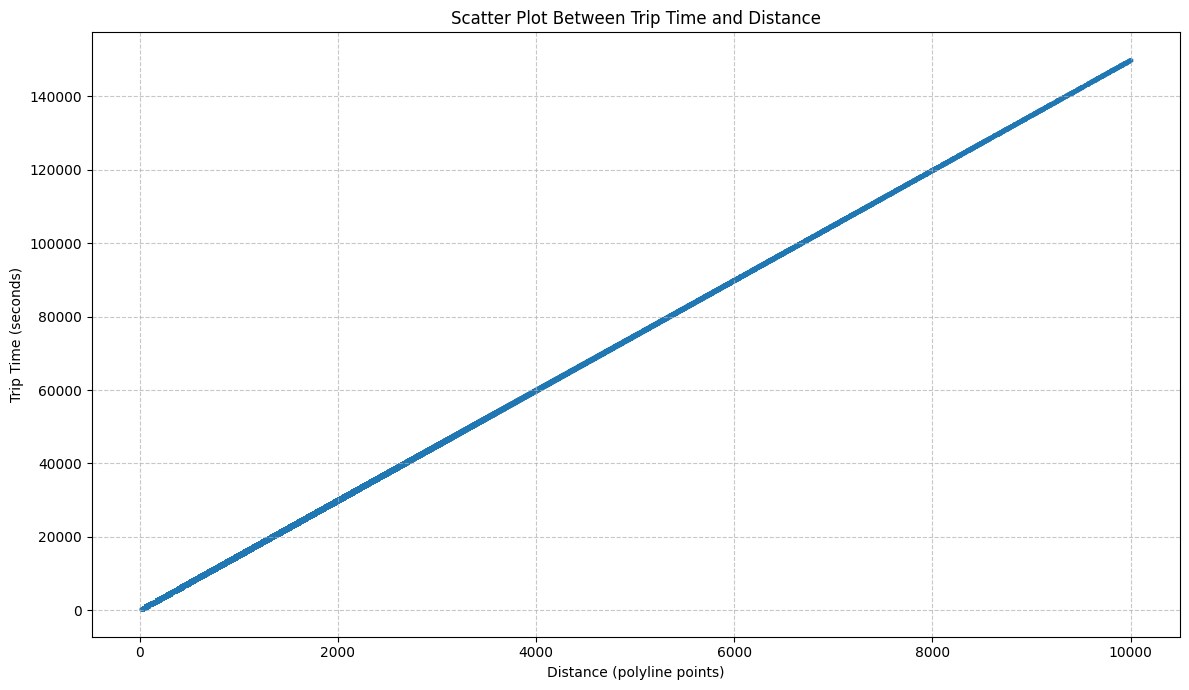

In [ ]:
import matplotlib.pyplot as plt

# Ensure 'trip_time' is available
if 'trip_time' not in taxidata_copy.columns:
    taxidata_copy['trip_time'] = taxidata_copy['LENGHT'] * 15

# Filter data for better visualization, similar to previous analysis
# Removing extreme outliers to make the main trend clearer
filtered_data = taxidata_copy[(taxidata_copy['LENGHT'] < 10000) & (taxidata_copy['trip_time'] < 200000)]

plt.figure(figsize=(12, 7))
plt.scatter(filtered_data['LENGHT'], filtered_data['trip_time'], alpha=0.5, s=5)
plt.title('Scatter Plot Between Trip Time and Distance')
plt.xlabel('Distance (polyline points)')
plt.ylabel('Trip Time (seconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

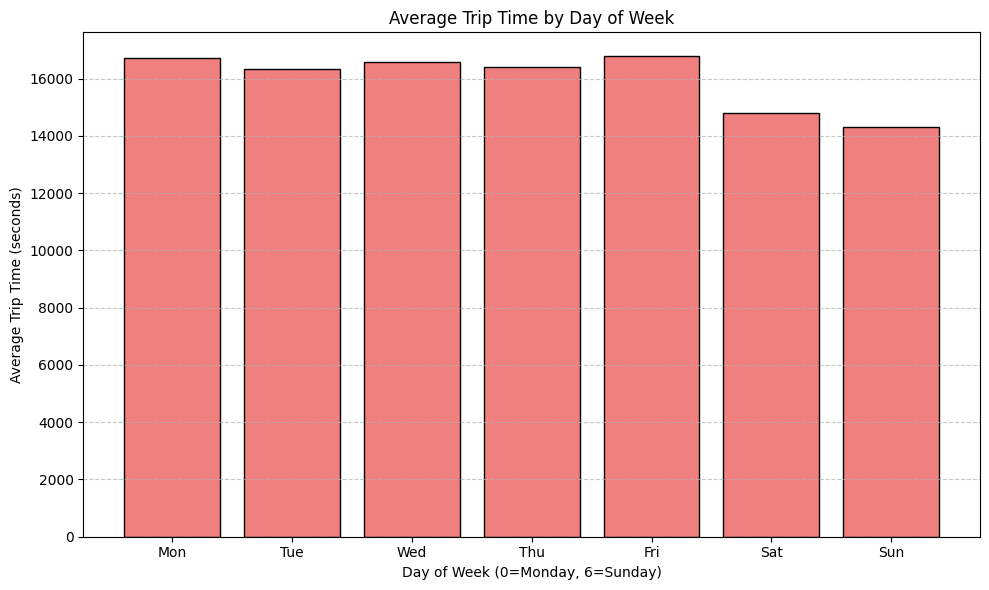

In [ ]:
taxidata_copy['trip_time'] = taxidata_copy['LENGHT'] * 15

avg_trip_time_by_day = taxidata_copy.groupby('DAY')['trip_time'].mean().reset_index()


plt.figure(figsize=(10, 6))
plt.bar(avg_trip_time_by_day['DAY'], avg_trip_time_by_day['trip_time'], color='lightcoral', edgecolor='black')


plt.title('Average Trip Time by Day of Week')


plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Trip Time (seconds)')


plt.xticks(avg_trip_time_by_day['DAY'], ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

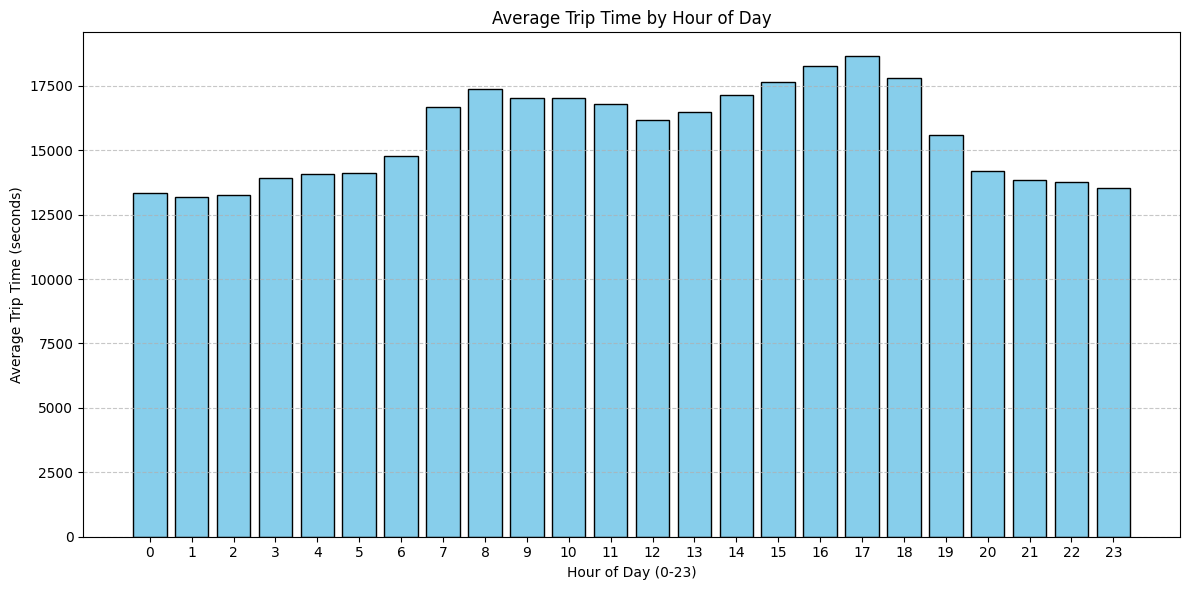

In [ ]:
taxidata_copy['trip_time'] = taxidata_copy['LENGHT'] * 15


avg_trip_time_by_hour = taxidata_copy.groupby('HOUR')['trip_time'].mean().reset_index()


plt.figure(figsize=(12, 6))
plt.bar(avg_trip_time_by_hour['HOUR'], avg_trip_time_by_hour['trip_time'], color='skyblue', edgecolor='black')


plt.title('Average Trip Time by Hour of Day')


plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Trip Time (seconds)')

plt.xticks(avg_trip_time_by_hour['HOUR'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [ ]:
avg_trip_time_by_hour = taxidata_copy.groupby('HOUR')['trip_time'].mean().reset_index()

# Find the busiest hour (hour with max average trip time)
busiest_hour_data = avg_trip_time_by_hour.loc[avg_trip_time_by_hour['trip_time'].idxmax()]
busiest_hour = busiest_hour_data['HOUR']
max_avg_trip_time = busiest_hour_data['trip_time']

# Find the least busy hour (hour with min average trip time)
least_busy_hour_data = avg_trip_time_by_hour.loc[avg_trip_time_by_hour['trip_time'].idxmin()]
least_busy_hour = least_busy_hour_data['HOUR']
min_avg_trip_time = least_busy_hour_data['trip_time']

# Calculate the overall average trip time
overall_avg_trip_time = avg_trip_time_by_hour['trip_time'].mean()

# Calculate the increase in trip time
increase_from_min = max_avg_trip_time - min_avg_trip_time
increase_from_overall_avg = max_avg_trip_time - overall_avg_trip_time

print(f"--- Trip Time Analysis for Busy Hours ---")
print(f"The busiest hour is Hour {int(busiest_hour)} with an average trip time of {max_avg_trip_time:.2f} seconds.")
print(f"The least busy hour is Hour {int(least_busy_hour)} with an average trip time of {min_avg_trip_time:.2f} seconds.")
print(f"The overall average trip time across all hours is {overall_avg_trip_time:.2f} seconds.")
print(f"\nIncrease in trip time during the busiest hour (Hour {int(busiest_hour)}):")
print(f"- Compared to the least busy hour (Hour {int(least_busy_hour)}): {increase_from_min:.2f} seconds")
print(f"- Compared to the overall average: {increase_from_overall_avg:.2f} seconds")
print("-----------------------------------------")

--- Trip Time Analysis for Busy Hours ---
The busiest hour is Hour 17 with an average trip time of 18640.21 seconds.
The least busy hour is Hour 1 with an average trip time of 13167.53 seconds.
The overall average trip time across all hours is 15605.37 seconds.

Increase in trip time during the busiest hour (Hour 17):
- Compared to the least busy hour (Hour 1): 5472.68 seconds
- Compared to the overall average: 3034.83 seconds
-----------------------------------------


Back up

In [ ]:
y_train_pred = random_regressor.predict(X_train)
y_test_pred = random_regressor.predict(X_test)

import joblib

# Define paths to save the model and scaler
model_save_path = '/content/drive/MyDrive/PolyU/Year2/EIE4117/models/random_forest_regressor_model.pkl'
scaler_save_path = '/content/drive/MyDrive/PolyU/Year2/EIE4117/models/standard_scaler.pkl'

# Create the directory if it doesn't exist
import os
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# Save the trained Random Forest model
joblib.dump(random_regressor, model_save_path)
print(f"Random Forest model saved to {model_save_path}")

# Save the fitted StandardScaler
joblib.dump(s, scaler_save_path)
print(f"StandardScaler saved to {scaler_save_path}")

In [ ]:
import pandas as pd
import numpy as np
import ast

# Reload the base data to ensure we start from a known state (or create the column if starting fresh)
taxidata_copy = pd.read_pickle('/content/drive/MyDrive/PolyU/Year2/EIE4117/dataset/taxidata_processed.pkl')

# Check if 'DROP_OFF_LOC' column exists. If not, create it.
if 'DROP_OFF_LOC' not in taxidata_copy.columns:
    print("Creating 'DROP_OFF_LOC' column...")
    # Ensure 'POLYLINE' column is treated as strings and then evaluated
    taxidata_copy['DROP_OFF_LOC'] = taxidata_copy['POLYLINE'].apply(lambda x: np.flip(ast.literal_eval(x)[-1], 0).tolist())
    print("'DROP_OFF_LOC' column created.")
else:
    print("'DROP_OFF_LOC' column already exists.")

# Save the updated DataFrame to the pickle file
taxidata_copy.to_pickle('/content/drive/MyDrive/PolyU/Year2/EIE4117/dataset/taxidata_processed2.pkl')
print("Updated data saved to taxidata_processed.pkl with 'DROP_OFF_LOC'.")

# Reload the DataFrame to ensure the current session uses the updated data
taxidata_copy = pd.read_pickle('/content/drive/MyDrive/PolyU/Year2/EIE4117/dataset/taxidata_processed2.pkl')
print("DataFrame reloaded successfully.")

display(taxidata_copy.head())